In [1]:
pip install notebook jupyterlab

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# For displaying all columns
pd.set_option("display.max_columns", None)

# CERT insider threat dataset
df_cert_email = pd.read_csv("datasets\email.csv")
df_cert_psych = pd.read_csv("datasets\psychometric.csv")

In [4]:
# UNSW-NB15 dataset
df_unsw1 = pd.read_csv("datasets\\UNSW_NB15_training-set.csv")
df_unsw2 = pd.read_csv("datasets\\UNSW_NB15_testing-set.csv")

In [5]:
# Cybersecurity attacks dataset
df_attacks = pd.read_csv("datasets\cybersecurity_attacks.csv")

In [6]:
# Wireshark traffic
df_wireshark = pd.read_csv("datasets\Midterm-Step2-Group-15.csv")

In [7]:
print(df_cert_email.head())

                         id                 date     user       pc  \
0  {R3I7-S4TX96FG-8219JWFF}  01/02/2010 07:11:45  LAP0338  PC-5758   
1  {R0R9-E4GL59IK-2907OSWJ}  01/02/2010 07:12:16  MOH0273  PC-6699   
2  {G2B2-A8XY58CP-2847ZJZL}  01/02/2010 07:13:00  LAP0338  PC-5758   
3  {A3A9-F4TH89AA-8318GFGK}  01/02/2010 07:13:17  LAP0338  PC-5758   
4  {E8B7-C8FZ88UF-2946RUQQ}  01/02/2010 07:13:28  MOH0273  PC-6699   

                                                  to  \
0  Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...   
1                        Odonnell-Gage@bellsouth.net   
2                         Penelope_Colon@netzero.com   
3                          Judith_Hayden@comcast.net   
4  Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...   

                                cc                          bcc  \
0  Nathaniel.Hunter.Heath@dtaa.com                          NaN   
1                              NaN                          NaN   
2                              NaN       

In [8]:
print(df_unsw1.head())

   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  sttl  dttl        sload  dload  sloss  dloss  sinpkt  dinpkt  \
0   90909.0902   254     0  180363632.0    0.0      0      0   0.011     0.0   
1  125000.0003   254     0  881000000.0    0.0      0      0   0.008     0.0   
2  200000.0051   254     0  854400000.0    0.0      0      0   0.005     0.0   
3  166666.6608   254     0  600000000.0    0.0      0      0   0.006     0.0   
4  100000.0025   254     0  850400000.0    0.0      0      0   0.010     0.0   

   sjit  djit  swin  stcpb  dtcpb  dwin  tcprtt  synack  ackdat  smean  dmean  \
0   0.0   0.0     0    

In [9]:
print(df_attacks.head())

             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data Malware Indicators  \
0  Qui natu

CERT Insider Threat: (2629979, 11)
UNSW-NB15 Training: (82332, 45)
Cyber Attacks: (40000, 25)
label
1    45332
0    37000
Name: count, dtype: int64
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


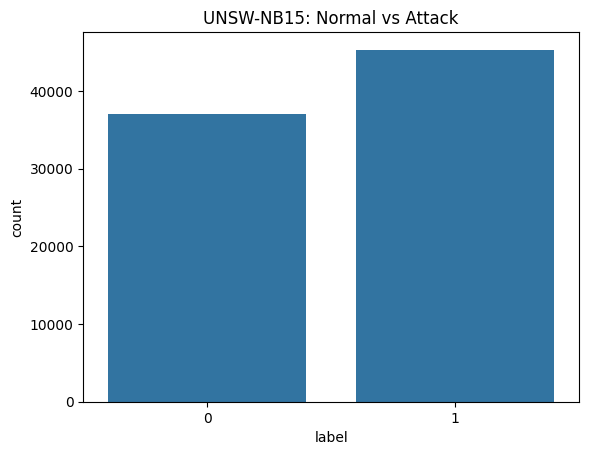

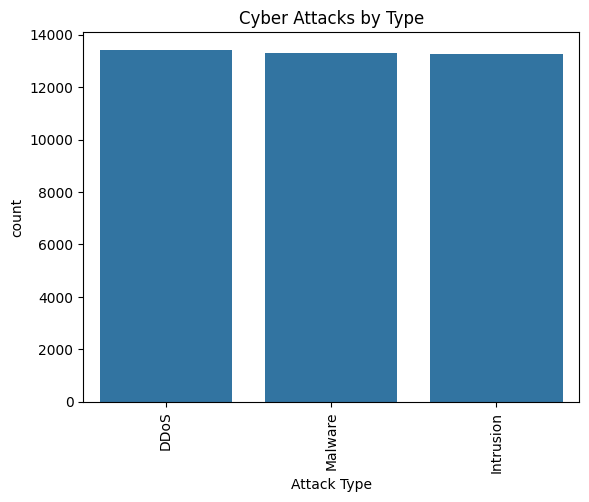

In [10]:
print("CERT Insider Threat:", df_cert_email.shape)
print("UNSW-NB15 Training:", df_unsw1.shape)
print("Cyber Attacks:", df_attacks.shape)

# # Visualization
# sns.countplot(data=df_unsw1, x="label")
# plt.show()

# Check class distribution
print(df_unsw1['label'].value_counts())   # normal vs attack
print(df_attacks['Attack Type'].value_counts())  # distribution of attack types

# Visualization for UNSW-NB15
sns.countplot(data=df_unsw1, x="label")
plt.title("UNSW-NB15: Normal vs Attack")
plt.show()

# Visualization for Cyber Attacks
sns.countplot(data=df_attacks, x="Attack Type", order=df_attacks['Attack Type'].value_counts().index)
plt.title("Cyber Attacks by Type")
plt.xticks(rotation=90)
plt.show()


In [11]:
# 4.
from sklearn.preprocessing import LabelEncoder, StandardScaler

# For UNSW-NB15
df_unsw = pd.concat([df_unsw1, df_unsw2])
X = df_unsw.drop(columns=["label"])
y = df_unsw["label"]

# Encode categorical columns
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
print(df_unsw1.columns)

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11147
           1       1.00      1.00      1.00     13553

    accuracy                           1.00     24700
   macro avg       1.00      1.00      1.00     24700
weighted avg       1.00      1.00      1.00     24700



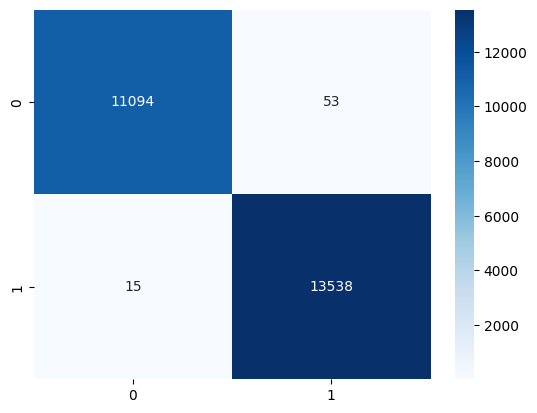

In [13]:
# Target
y = df_unsw1['label']

# Drop label and attack_cat from features
X = df_unsw1.drop(['label', 'attack_cat'], axis=1)
# One-hot encode categorical features
X = pd.get_dummies(X, columns=['proto', 'service', 'state'])

# Train-test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Split first, then scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.show()


c:\Minor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Minor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Minor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                precision    recall  f1-score   support

      Analysis       0.22      0.06      0.09       203
      Backdoor       0.00      0.00      0.00       175
           DoS       0.39      0.35      0.37      1227
      Exploits       0.64      0.73      0.69      3340
       Fuzzers       0.70      0.65      0.67      1819
       Generic       1.00      0.97      0.98      5661
        Normal       0.95      0.99      0.97     11100
Reconnaissance       0.92      0.78      0.84      1049
     Shellcode       0.59      0.42      0.49       113
         Worms       0.00      0.00      0.00        13

      accuracy                           0.87     24700
     macro avg       0.54      0.49      0.51     24700
  weighted avg       0.86      0.87      0.86     24700



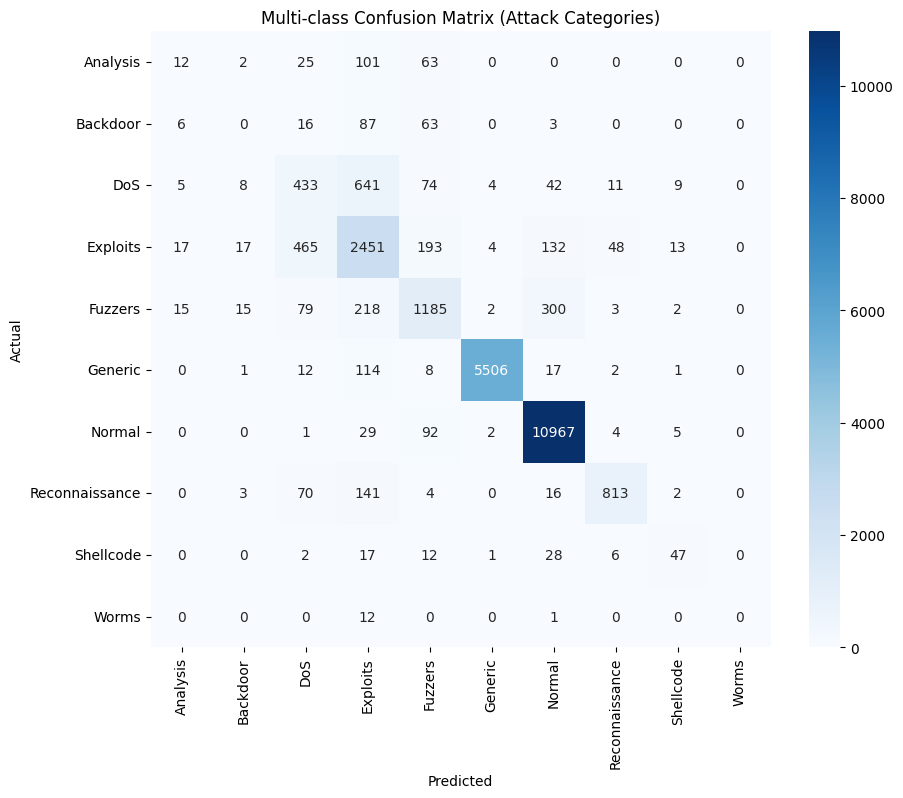

In [14]:
# Target: attack category (multi-class)
y = df_unsw1['attack_cat']

# Drop target columns from features
X = df_unsw1.drop(['label', 'attack_cat', 'id'], axis=1)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical features
categorical_cols = X.select_dtypes(include=['object']).columns

# One-hot encode categorical features
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler(with_mean=False)  # with_mean=False for sparse data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-class Confusion Matrix (Attack Categories)")
plt.show()


In [15]:
import pandas as pd
import json

# Read JSONL safely line by line
records = []
with open("datasets\Forensic_toolkit_dataset.jsonl", "r") as f:
    for line in f:
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print("Skipping bad line:", line[:100], e)

df_forensic = pd.DataFrame(records)
# print(df_forensic.head())
print(df_forensic.columns)


# # Example: suspicious files
# suspicious_files = df_forensic[df_forensic['file_extension'].isin(['exe','dll','bat'])]
# print(suspicious_files)

import re

# Extract file extensions from the "commands" field
def extract_extensions(cmds):
    if isinstance(cmds, list):  # some rows have list of commands
        text = " ".join(cmds)
    else:
        text = str(cmds)
    return re.findall(r'\.([a-zA-Z0-9]+)\b', text)

df_forensic['file_extension'] = df_forensic['commands'].apply(extract_extensions)

# Flatten + count extensions
all_extensions = [ext.lower() for sublist in df_forensic['file_extension'] for ext in sublist]
ext_counts = pd.Series(all_extensions).value_counts()

print("🔍 File extension frequency in forensic commands:")
print(ext_counts.head(20))

# Filter only suspicious ones
suspicious_files = df_forensic[df_forensic['file_extension'].apply(
    lambda exts: any(ext in ['exe','dll','bat'] for ext in [e.lower() for e in exts])
)]
print("\n⚠️ Tools mentioning suspicious file extensions:")
print(suspicious_files[['tool_name','file_extension','commands']])

Skipping bad line: {"id":230,"tool_name":"Velociraptor","commands":["velociraptor -c config.yaml -o evidence_dir"],"usa Extra data: line 1 column 332 (char 331)
Skipping bad line: {"id":231,"tool_name":"ExifTool","commands":["exiftool -a file.jpg -o metadata.json"],"usage":"Extra Extra data: line 1 column 313 (char 312)
Skipping bad line: {"id":233,"tool_name":"JFAV","commands":["jfav -i evidence.xml -o 3d_visual.html"],"usage":"Visualiz Extra data: line 1 column 353 (char 352)
Index(['id', 'tool_name', 'commands', 'usage', 'description', 'link',
       'system'],
      dtype='object')
🔍 File extension frequency in forensic commands:
json    87
dd      50
exe     28
csv     24
dmp     21
py      11
pcap    10
hive     9
txt      8
db       7
yml      5
xml      4
ps1      4
zip      4
com      3
yaml     3
html     3
bin      3
tar      3
lime     3
Name: count, dtype: int64

⚠️ Tools mentioning suspicious file extensions:
                                      tool_name    file_extensi

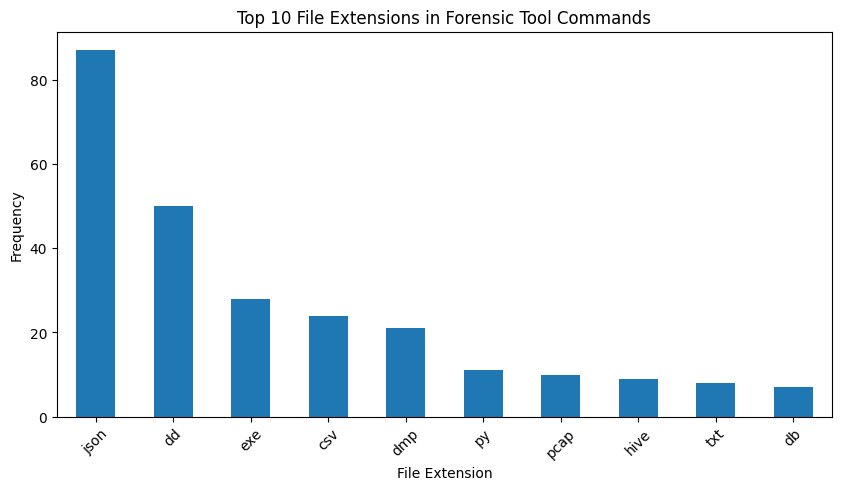

In [16]:
import matplotlib.pyplot as plt

# Plot top 10 extensions
ext_counts.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 File Extensions in Forensic Tool Commands")
plt.xlabel("File Extension")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [17]:
suspicious_list = ['exe','dd','bat']
print("Suspicious extension counts:")
print(ext_counts[ext_counts.index.isin(suspicious_list)])

Suspicious extension counts:
dd     50
exe    28
bat     1
Name: count, dtype: int64


In [18]:
# Save suspicious tools list to CSV
suspicious_files.to_csv("suspicious_tools.csv", index=False)

# Save all extension counts
ext_counts.to_csv("extension_counts.csv")

In [19]:
print(list(df_wireshark.columns))

['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']


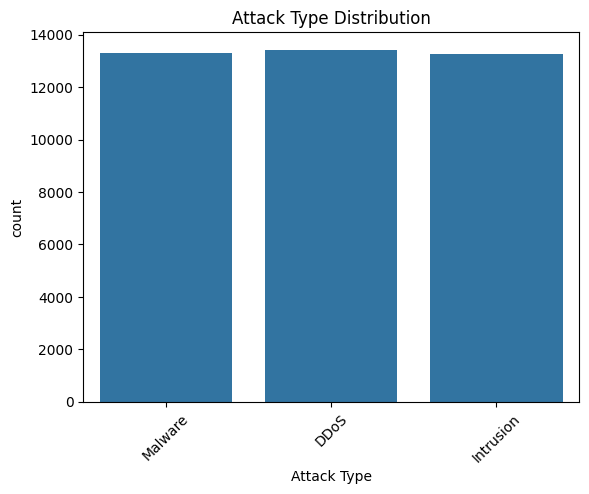

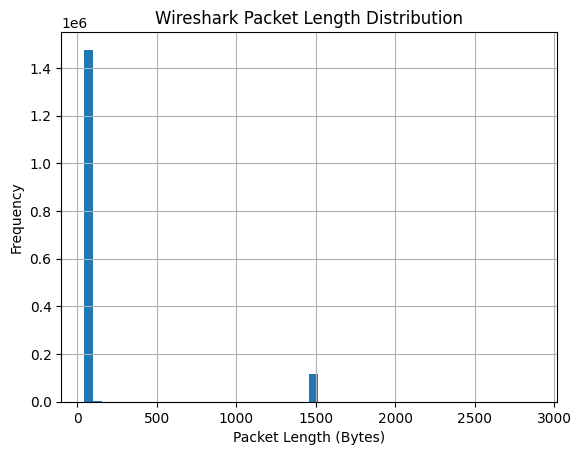

In [20]:
# 8.
# Attack type distribution
sns.countplot(data=df_attacks, x="Attack Type")
plt.xticks(rotation=45)
plt.title("Attack Type Distribution")
plt.show()

# Wireshark traffic length
df_wireshark['Length'].hist(bins=50)
plt.title("Wireshark Packet Length Distribution")
plt.xlabel("Packet Length (Bytes)")
plt.ylabel("Frequency")
plt.show()


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = df_unsw1.copy()
y = df['attack_cat']

forensic_fields = df[['id', 'dur', 'proto', 'service', 'state']]

feature_cols = df.columns.difference(['attack_cat', 'label', 'id'])
categorical_cols = ['proto', 'service', 'state']
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# Apply scaler/encoder etc. on X


X_raw = df[feature_cols]

X_train_raw, X_test_raw, y_train, y_test, forensic_train, forensic_test = train_test_split(
    X_raw, y, forensic_fields, test_size=0.3, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'
)

X_train = preprocess.fit_transform(X_train_raw)
X_test  = preprocess.transform(X_test_raw)


In [22]:
import json

events = []
for i, (true, pred) in enumerate(zip(y_test.to_numpy(), y_pred)):
    row = forensic_test.iloc[i]
    events.append({
        "id": int(row["id"]),
        "source_node": str(row["proto"]),
        "destination_node": str(row["service"]),
        "state": str(row["state"]),
        "attack_type": str(pred),
        "true_label": str(true),
        "duration": float(row["dur"]),
        "timestamp": f"t{int(row['id'])}"
    })

with open("attack_events.json", "w") as f:
    json.dump(events, f, indent=2)

print("✅ Exported", len(events), "events to attack_events.json")


✅ Exported 24700 events to attack_events.json


In [23]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


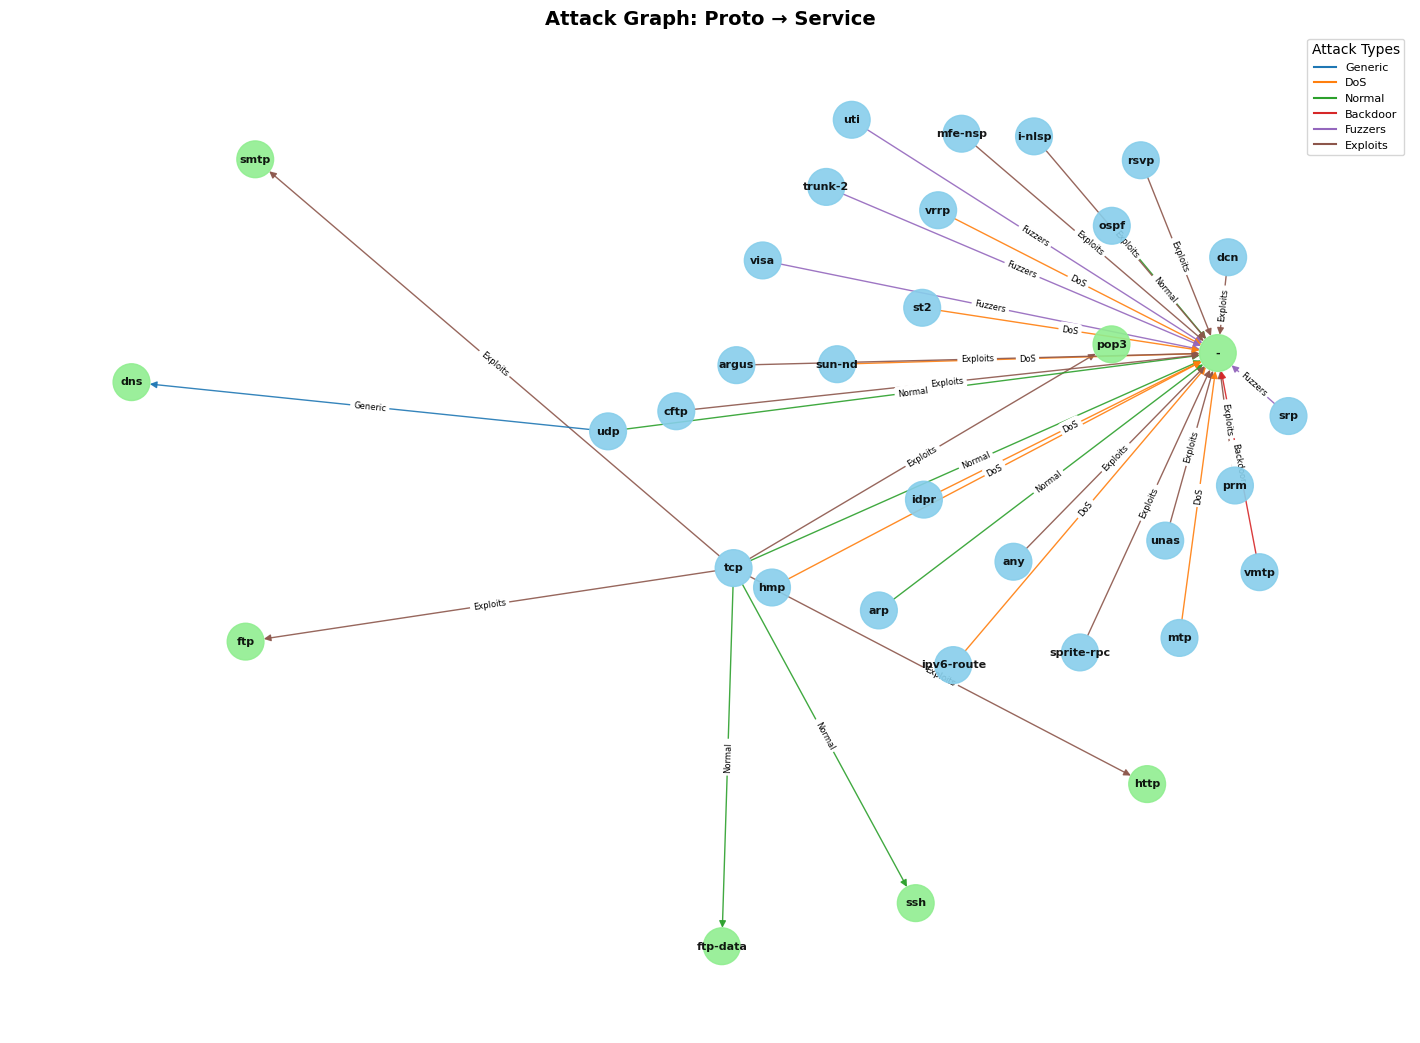

In [24]:
import json
import networkx as nx
import matplotlib.pyplot as plt

with open("attack_events.json", "r") as f:
    events = json.load(f)

G = nx.DiGraph()
for e in events[:500]:
    G.add_node(e["source_node"], kind="proto")
    G.add_node(e["destination_node"], kind="service")
    G.add_edge(e["source_node"], e["destination_node"], attack=e["attack_type"])

# Assign colors to node types
node_colors = []
for node, data in G.nodes(data=True):
    if data["kind"] == "proto":
        node_colors.append("skyblue")
    else:
        node_colors.append("lightgreen")

# Assign colors to edges by attack type
attack_types = list(set(nx.get_edge_attributes(G, "attack").values()))
attack_color_map = {atype: plt.cm.tab10(i % 10) for i, atype in enumerate(attack_types)}
edge_colors = [attack_color_map[data["attack"]] for _, _, data in G.edges(data=True)]

# Layout and plotting
pos = nx.spring_layout(G, k=0.7, seed=42)
plt.figure(figsize=(14, 10))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=700,
    node_color=node_colors,
    edge_color=edge_colors,
    alpha=0.9,
    font_size=8,
    font_weight="bold"
)

# Draw edge labels (attack types)
edge_labels = nx.get_edge_attributes(G, "attack")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

# Legend for edge colors
for attack, color in attack_color_map.items():
    plt.plot([], [], color=color, label=attack)
plt.legend(title="Attack Types", fontsize=8, loc="best")

plt.title("Attack Graph: Proto → Service", fontsize=14, fontweight="bold")
plt.show()


In [25]:
import pandas as pd

df_events = pd.DataFrame(events)
df_events['t'] = df_events['timestamp'].str.extract(r'(\d+)').astype(int)
df_events = df_events.sort_values('t')

for T, group in df_events.groupby('t'):
    print(f"Time {T}: {len(group)} events")
    for _, r in group.iterrows():
        print(f"{r['source_node']} → {r['destination_node']} | {r['attack_type']} | {r['state']}")

Time 1: 1 events
udp → - | Normal | INT
Time 3: 1 events
udp → - | Normal | INT
Time 4: 1 events
udp → - | Normal | INT
Time 6: 1 events
udp → - | Normal | INT
Time 10: 1 events
arp → - | Normal | INT
Time 11: 1 events
arp → - | Normal | INT
Time 12: 1 events
arp → - | Normal | INT
Time 14: 1 events
udp → - | Normal | INT
Time 15: 1 events
udp → - | Exploits | INT
Time 16: 1 events
udp → - | Normal | INT
Time 20: 1 events
udp → - | Normal | INT
Time 22: 1 events
udp → - | Normal | INT
Time 27: 1 events
udp → - | Normal | INT
Time 32: 1 events
tcp → - | Normal | FIN
Time 39: 1 events
arp → - | Normal | INT
Time 43: 1 events
tcp → - | Normal | FIN
Time 45: 1 events
tcp → - | Normal | FIN
Time 48: 1 events
tcp → - | Normal | FIN
Time 52: 1 events
tcp → - | Normal | FIN
Time 54: 1 events
tcp → - | Normal | REQ
Time 57: 1 events
tcp → - | Normal | FIN
Time 60: 1 events
tcp → - | Normal | REQ
Time 62: 1 events
tcp → - | Normal | REQ
Time 64: 1 events
tcp → - | Normal | REQ
Time 66: 1 events


KeyboardInterrupt: 

In [ ]:
# ===== 1) Load data (UNSW-NB15 training CSV) =====
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

# Adjust path if needed
unsw_path = "datasets\\UNSW_NB15_training-set.csv"
# or
# unsw_path = r"datasets\UNSW_NB15_training-set.csv"
df = pd.read_csv(unsw_path)

# Keep only the features you also have in attack_events.json
use_cols = ["dur", "proto", "service", "state", "attack_cat"]
df = df[use_cols].dropna()

X = df[["dur", "proto", "service", "state"]]
y = df["attack_cat"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ===== 2) Build a FULL Pipeline (preprocess + model) =====
numeric_cols = ["dur"]
categorical_cols = ["proto", "service", "state"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

clf.fit(X_train, y_train)

print(classification_report(y_val, clf.predict(X_val)))

# ===== 3) Save the WHOLE pipeline =====
joblib.dump(clf, "attack_classifier.pkl")
print("✅ Saved full pipeline to attack_classifier.pkl")


                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       169
      Backdoor       0.00      0.00      0.00       146
           DoS       0.33      0.36      0.35      1022
      Exploits       0.44      0.49      0.47      2783
       Fuzzers       0.28      0.23      0.25      1515
       Generic       0.97      0.97      0.97      4718
        Normal       0.79      0.84      0.81      9250
Reconnaissance       0.15      0.08      0.11       874
     Shellcode       0.02      0.01      0.01        95
         Worms       0.00      0.00      0.00        11

      accuracy                           0.70     20583
     macro avg       0.30      0.30      0.30     20583
  weighted avg       0.68      0.70      0.69     20583

✅ Saved full pipeline to attack_classifier.pkl


In [ ]:
import pandas as pd

# Load the attack_events.json
df = pd.read_json("attack_events.json")

print(df.head())
print(df.info())


      id source_node destination_node state attack_type true_label  duration  \
0  35201         tcp                -   FIN      Normal     Normal  0.031370   
1  58540         tcp                -   FIN      Normal    Fuzzers  1.056885   
2  28593         tcp                -   FIN      Normal     Normal  0.020936   
3  52203         tcp                -   FIN    Exploits   Backdoor  0.220550   
4  78734         udp                -   INT      Normal     Normal  0.000010   

  timestamp  
0    t35201  
1    t58540  
2    t28593  
3    t52203  
4    t78734  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24700 entries, 0 to 24699
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                24700 non-null  int64  
 1   source_node       24700 non-null  object 
 2   destination_node  24700 non-null  object 
 3   state             24700 non-null  object 
 4   attack_type       24700 non-null  object

In [ ]:
X = df[['source_node', 'destination_node', 'state', 'duration']]
y = df['attack_type']

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
for col in ['source_node', 'destination_node', 'state']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Encode target labels
y = LabelEncoder().fit_transform(y.astype(str))


C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\2261587649.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\2261587649.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\2261587649.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7625506072874494
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         8
           1       1.00      0.70      0.82        10
           2       0.74      0.83      0.78       212
           3       0.63      0.59      0.61       807
           4       0.33      0.32      0.33       339
           5       0.99      0.99      0.99      1138
           6       0.78      0.83      0.80      2228
           7       0.18      0.10      0.13       175
           8       0.00      0.00      0.00        23

    accuracy                           0.76      4940
   macro avg       0.60      0.57      0.58      4940
weighted avg       0.75      0.76      0.75      4940



In [ ]:
import pickle

with open("attack_classifier.pkl", "wb") as f:
    pickle.dump(model, f)


C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\2404598498.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(10, len(classes)))


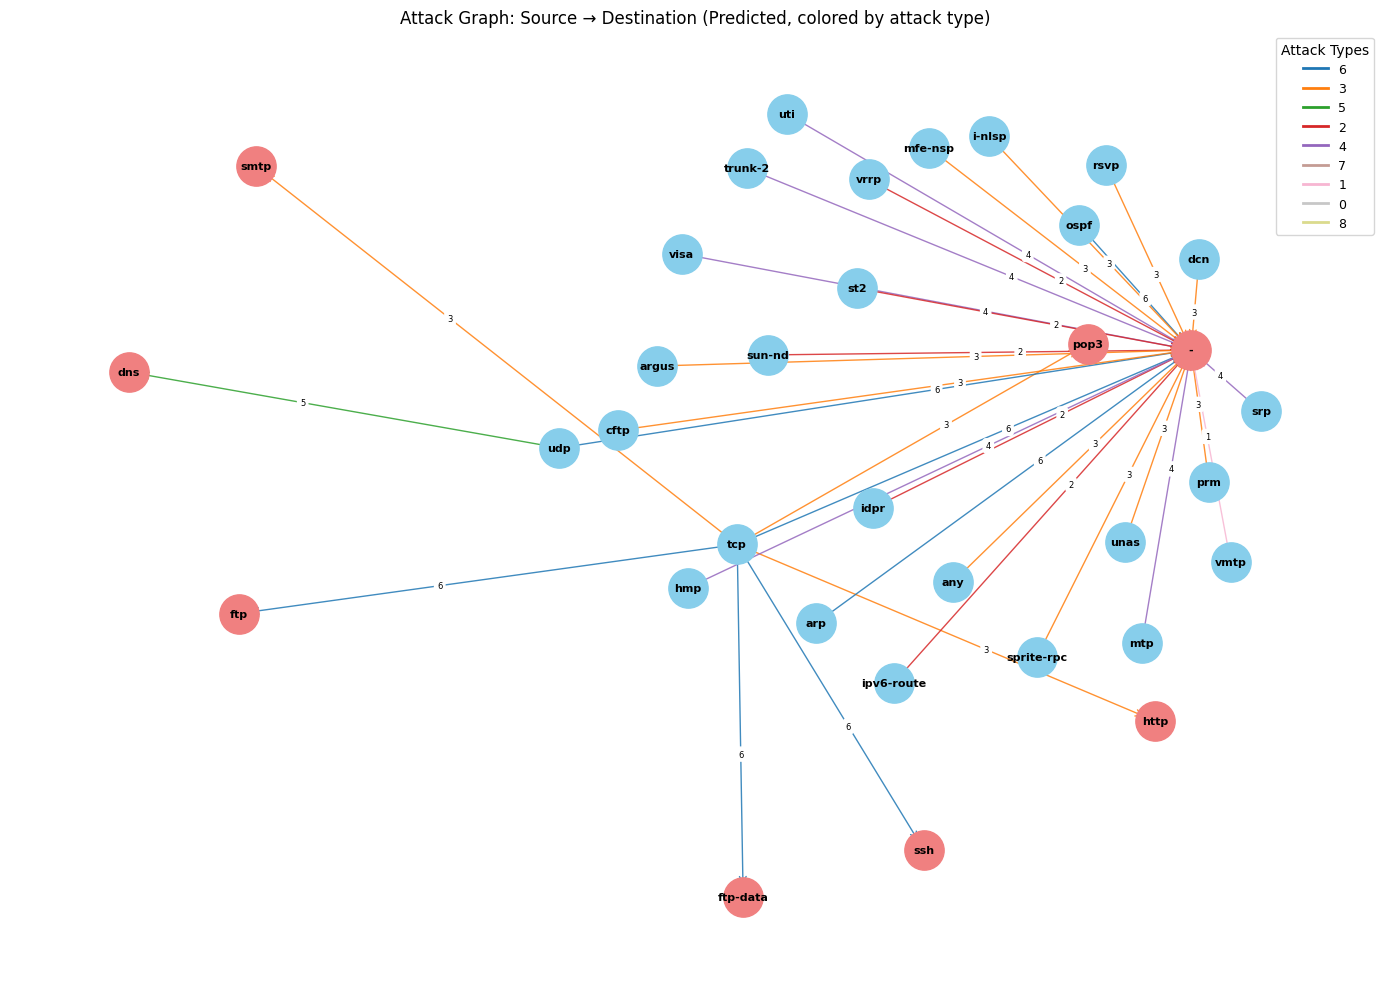

In [ ]:
# # =====================
# # 6. Add Predictions back to df
# # =====================
# df_encoded = df.copy()
# for col in ['source_node', 'destination_node', 'state']:
#     le = LabelEncoder()
#     df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# df["prediction"] = model.predict(df_encoded[['source_node', 'destination_node', 'state', 'duration']])

# # =====================
# # 7. Build Attack Graph
# # =====================
# G = nx.DiGraph()
# for e in df.to_dict(orient="records")[:500]:  # limit to 500 edges
#     src = e.get("source_node", "src")
#     dst = e.get("destination_node", "dst")
#     G.add_node(src, kind="proto")
#     G.add_node(dst, kind="service")
#     G.add_edge(src, dst, attack=e["prediction"])

# # Split nodes by type
# proto_nodes = [n for n, a in G.nodes(data=True) if a.get("kind") == "proto"]
# service_nodes = [n for n, a in G.nodes(data=True) if a.get("kind") == "service"]

# # Color map
# classes = list(pd.Series(df["prediction"]).unique())
# cmap = plt.cm.get_cmap("tab20", max(10, len(classes)))
# attack_colors = {cls: cmap(i % cmap.N) for i, cls in enumerate(classes)}

# # Edge colors
# edge_colors = [attack_colors[d["attack"]] for _, _, d in G.edges(data=True)]

# # Layout + draw
# pos = nx.spring_layout(G, k=0.8, seed=42)
# plt.figure(figsize=(14, 10))

# nx.draw_networkx_nodes(G, pos, nodelist=proto_nodes, node_color="skyblue", node_size=800, label="Source Node")
# nx.draw_networkx_nodes(G, pos, nodelist=service_nodes, node_color="lightcoral", node_size=800, label="Destination Node")
# nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color=edge_colors, alpha=0.85)
# nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")

# edge_labels = nx.get_edge_attributes(G, "attack")
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, label_pos=0.6, rotate=False)

# legend_elements = [Line2D([0], [0], color=c, lw=2, label=a) for a, c in attack_colors.items()]
# plt.legend(handles=legend_elements, title="Attack Types", fontsize=9, loc="best")

# plt.title("Attack Graph: Source → Destination (Predicted, colored by attack type)")
# plt.axis("off")
# plt.tight_layout()
# plt.show()


from matplotlib.lines import Line2D
# =====================
# 6. Add Predictions back to df
# =====================
df_encoded = df.copy()
for col in ['source_node', 'destination_node', 'state']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df["prediction"] = model.predict(df_encoded[['source_node', 'destination_node', 'state', 'duration']])

# =====================
# 7. Build Attack Graph
# =====================
G = nx.DiGraph()
for e in df.to_dict(orient="records")[:500]:  # limit to 500 edges
    src = e.get("source_node", "src")
    dst = e.get("destination_node", "dst")
    G.add_node(src, kind="proto")
    G.add_node(dst, kind="service")
    G.add_edge(src, dst, attack=e["prediction"])

# Split nodes by type
proto_nodes = [n for n, a in G.nodes(data=True) if a.get("kind") == "proto"]
service_nodes = [n for n, a in G.nodes(data=True) if a.get("kind") == "service"]

# Color map
classes = list(pd.Series(df["prediction"]).unique())
cmap = plt.cm.get_cmap("tab20", max(10, len(classes)))
attack_colors = {cls: cmap(i % cmap.N) for i, cls in enumerate(classes)}

# Edge colors
edge_colors = [attack_colors[d["attack"]] for _, _, d in G.edges(data=True)]

# Layout + draw
pos = nx.spring_layout(G, k=0.8, seed=42)
plt.figure(figsize=(14, 10))

nx.draw_networkx_nodes(G, pos, nodelist=proto_nodes, node_color="skyblue", node_size=800, label="Source Node")
nx.draw_networkx_nodes(G, pos, nodelist=service_nodes, node_color="lightcoral", node_size=800, label="Destination Node")
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color=edge_colors, alpha=0.85)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")

edge_labels = nx.get_edge_attributes(G, "attack")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, label_pos=0.6, rotate=False)

legend_elements = [Line2D([0], [0], color=c, lw=2, label=a) for a, c in attack_colors.items()]
plt.legend(handles=legend_elements, title="Attack Types", fontsize=9, loc="best")

plt.title("Attack Graph: Source → Destination (Predicted, colored by attack type)")
plt.axis("off")
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\2867879426.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  attack_events["timestamp"] = pd.to_datetime(attack_events["timestamp"], errors="coerce")


         id source_node destination_node state     attack_type  \
11014  1678        ospf                -   INT        Exploits   
18668  1679   ipv6-opts                -   INT        Exploits   
2565   1699         igp                -   INT             DoS   
8426   1704         gre                -   INT        Exploits   
21789  1705         udp                -   INT  Reconnaissance   

           true_label  duration  timestamp  
11014             DoS  0.921987 1678-01-01  
18668        Analysis  0.000005 1679-01-01  
2565   Reconnaissance  0.000003 1699-01-01  
8426         Exploits  0.000009 1704-01-01  
21789  Reconnaissance  0.000009 1705-01-01  


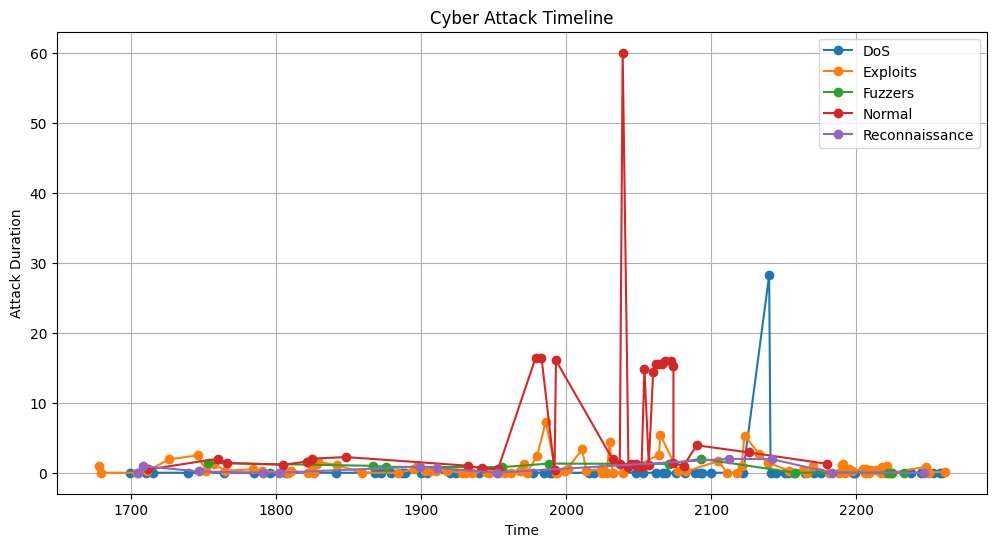

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load attack events
attack_events = pd.read_json("attack_events.json")

# Convert timestamp to datetime safely (invalid ones -> NaT)
attack_events["timestamp"] = pd.to_datetime(attack_events["timestamp"], errors="coerce")

# Drop invalid timestamps
attack_events = attack_events.dropna(subset=["timestamp"])

# Sort by time
attack_events = attack_events.sort_values("timestamp")

# Quick look
print(attack_events.head())

# Plot attack timeline
plt.figure(figsize=(12, 6))
for attack_type, group in attack_events.groupby("attack_type"):
    plt.plot(group["timestamp"], group["duration"], marker="o", linestyle="-", label=attack_type)

plt.title("Cyber Attack Timeline")
plt.xlabel("Time")
plt.ylabel("Attack Duration")
plt.legend()
plt.grid(True)
plt.show()


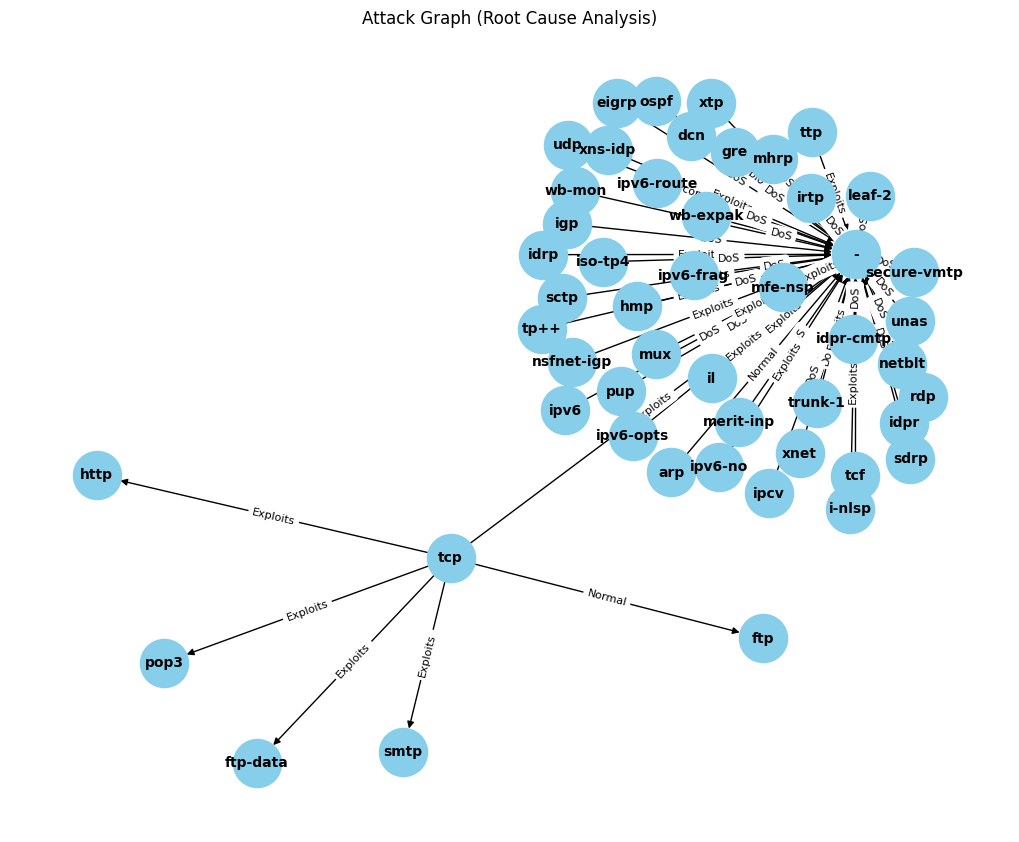

Possible Root Cause Nodes: ['tcp']


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges from source to destination
for _, row in attack_events.iterrows():
    G.add_edge(row["source_node"], row["destination_node"], attack_type=row["attack_type"], duration=row["duration"])

# Plot graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_size=1200, node_color="skyblue", font_size=10, font_weight="bold", arrows=True)
edge_labels = nx.get_edge_attributes(G, 'attack_type')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Attack Graph (Root Cause Analysis)")
plt.show()

# Identify root causes (nodes with high out-degree)
root_causes = [node for node, out_degree in G.out_degree() if out_degree > 2]
print("Possible Root Cause Nodes:", root_causes)


C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\870610961.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="attack_type", order=df["attack_type"].value_counts().index, palette="viridis")


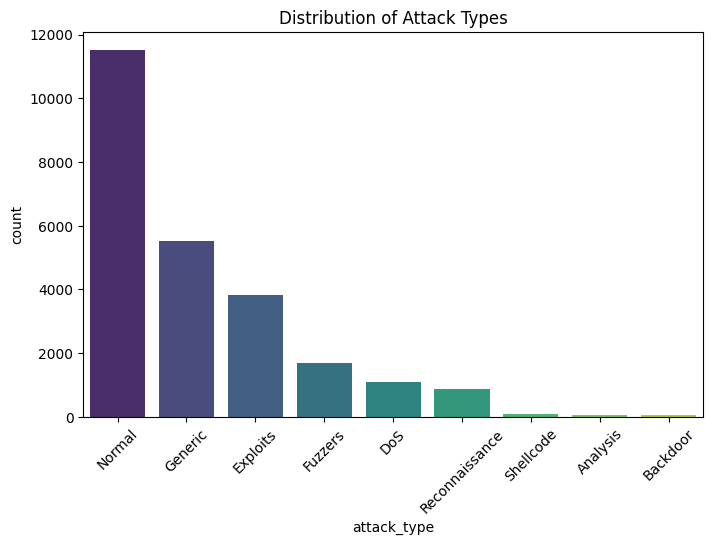

C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\870610961.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="state", order=df["state"].value_counts().index, palette="coolwarm")


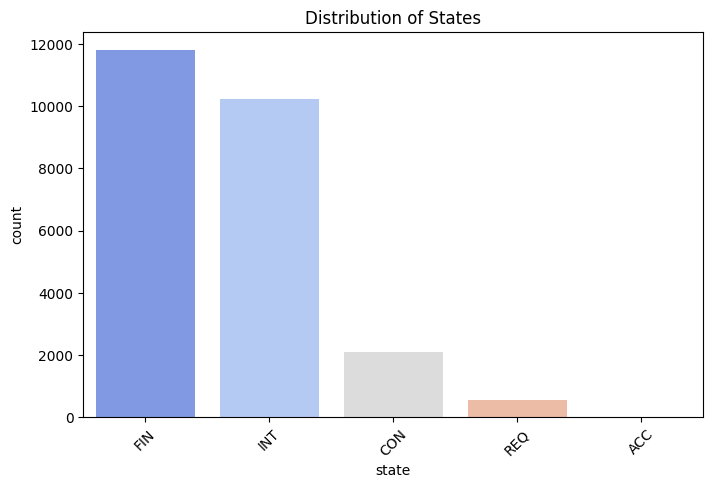

C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\870610961.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="true_label", palette="Set2")


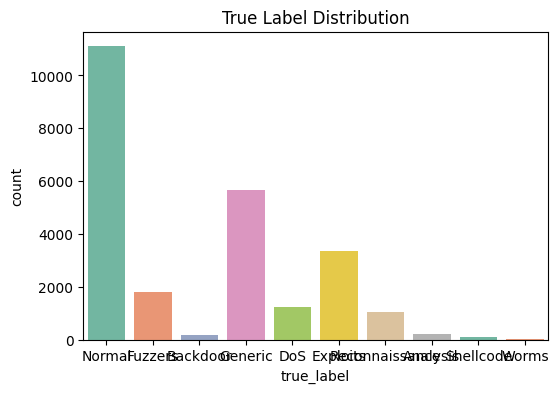

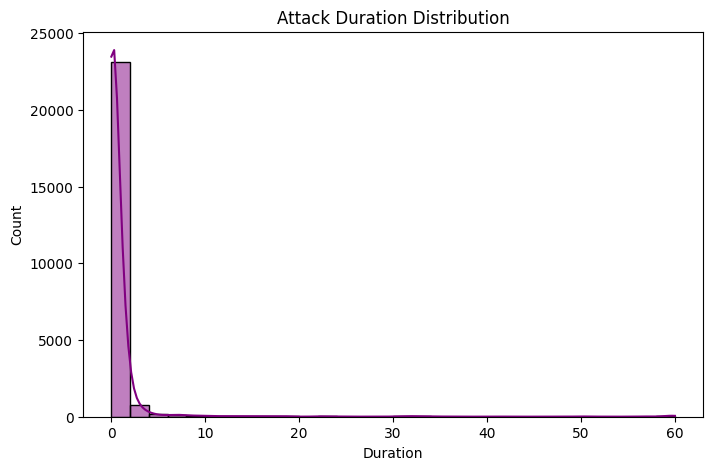

C:\Users\DELL\AppData\Local\Temp\ipykernel_8212\870610961.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")


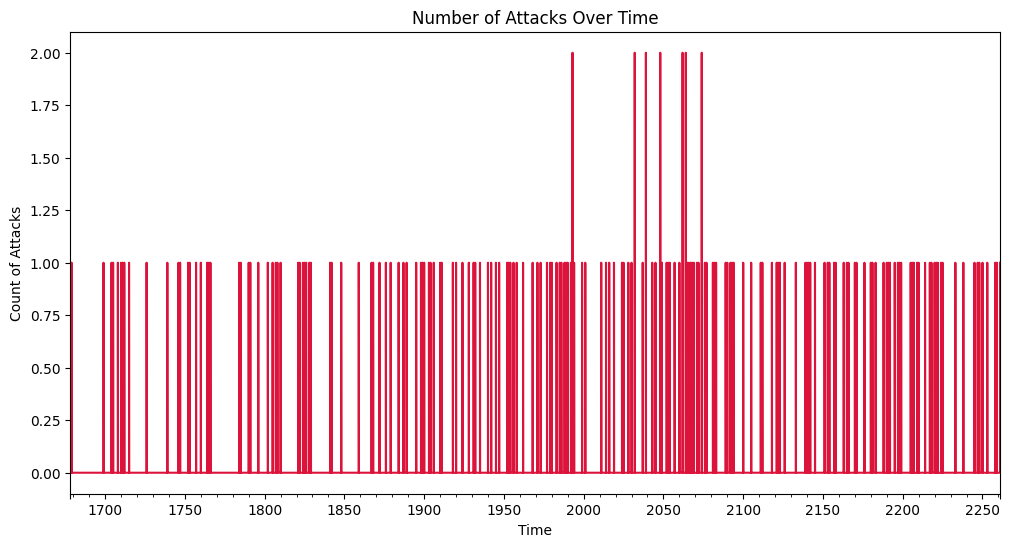

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Attack Types
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="attack_type", order=df["attack_type"].value_counts().index, palette="viridis")
plt.title("Distribution of Attack Types")
plt.xticks(rotation=45)
plt.show()

# 2. Distribution of States
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="state", order=df["state"].value_counts().index, palette="coolwarm")
plt.title("Distribution of States")
plt.xticks(rotation=45)
plt.show()

# 3. True Label Distribution (Normal vs Attack)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="true_label", palette="Set2")
plt.title("True Label Distribution")
plt.show()

# 4. Attack Duration Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["duration"], bins=30, kde=True, color="purple")
plt.title("Attack Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.show()

# Ensure timestamp is in datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Drop rows where timestamp could not be parsed
df = df.dropna(subset=["timestamp"])

# 5. Attacks over Time
plt.figure(figsize=(12,6))
df.set_index("timestamp")["attack_type"].resample("1h").count().plot(color="crimson")
plt.title("Number of Attacks Over Time")
plt.xlabel("Time")
plt.ylabel("Count of Attacks")
plt.show()



In [ ]:
pip install  pythreejs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install trimesh

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install pygltflib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import networkx as nx
from networkx.readwrite import json_graph
import json
from pythreejs import *
import trimesh
import numpy as np
import pygltflib

# Step 5: Convert Attack Graph to GLTF

def graph_to_gltf(G, filename="attack_graph.gltf"):
    # Convert nodes to 3D positions (force-directed layout in 3D)
    pos = nx.spring_layout(G, dim=3, seed=42)

    # Create a Trimesh scene
    scene = trimesh.Scene()

    # Add nodes as spheres
    for node, coords in pos.items():
        sphere = trimesh.creation.icosphere(subdivisions=2, radius=0.1)
        sphere.apply_translation(coords)
        sphere.visual.face_colors = [200, 50, 50, 255]  # red
        scene.add_geometry(sphere, node)

    # Add edges as cylinders
    for u, v in G.edges():
        start, end = pos[u], pos[v]
        vec = np.array(end) - np.array(start)
        length = np.linalg.norm(vec)

        if length > 0:
            cylinder = trimesh.creation.cylinder(radius=0.03, height=length, sections=12)
            # Move cylinder midpoint
            cylinder.apply_translation(start + vec / 2)
            scene.add_geometry(cylinder)

    # Export to GLTF
    scene.export(filename)
    print(f"✅ Attack graph exported to {filename}")

# # Example usage with your attack graph G
# graph_to_gltf(G, "attack_graph.gltf")
graph_to_gltf(G, "attack_graph.glb")


✅ Attack graph exported to attack_graph.glb


In [ ]:
import networkx as nx
import numpy as np
from pythreejs import *
from pygltflib import GLTF2, Scene, Node, Mesh, Buffer, BufferView, Accessor, Asset, Primitive
import json

def graph_to_glb(G, filename="attack_graph.glb"):
    nodes = list(G.nodes())
    positions = []
    edges = []

    # spring layout positions
    pos = nx.spring_layout(G, seed=42, dim=3)

    for node, coords in pos.items():
        positions.append([coords[0]*10, coords[1]*10, coords[2]*10])

    for u, v, data in G.edges(data=True):
        edges.append((nodes.index(u), nodes.index(v)))

    # ✅ instead of writing GLTF + external BIN, write single .glb
    from trimesh.exchange import gltf
    import trimesh

    # build simple spheres for nodes
    spheres = []
    for i, p in enumerate(positions):
        spheres.append(trimesh.creation.icosphere(radius=0.3).apply_translation(p))

    # build simple cylinders for edges
    cylinders = []
    for u, v in edges:
        start = positions[u]
        end = positions[v]
        vec = np.array(end) - np.array(start)
        length = np.linalg.norm(vec)
        if length > 0:
            cyl = trimesh.creation.cylinder(radius=0.1, height=length)
            cyl.apply_translation((np.array(start) + np.array(end)) / 2)
            cylinders.append(cyl)

    scene = trimesh.Scene(spheres + cylinders)
    scene.export(filename)   # ✅ this creates .glb
    print(f"✅ Attack graph exported to {filename}")


In [ ]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import networkx as nx
# import numpy as np
# from pythreejs import *
# from IPython.display import display

# # Example graph
# G = nx.erdos_renyi_graph(10, 0.3)

# # 3D layout
# pos = nx.spring_layout(G, dim=3, seed=42)

# # Node positions as numpy array
# node_positions = np.array([pos[n] for n in G.nodes()]) * 10

# # Create nodes (spheres)
# node_meshes = []
# for p in node_positions:
#     sphere = Mesh(
#         geometry=SphereGeometry(radius=0.3),
#         material=MeshBasicMaterial(color='orange'),
#         position=p.tolist()
#     )
#     node_meshes.append(sphere)

# # Create edges (lines)
# lines = []
# for u, v in G.edges():
#     start = node_positions[u]
#     end = node_positions[v]
#     line = Line(
#         geometry=BufferGeometry(attributes={
#             'position': BufferAttribute(np.array([start, end], dtype=np.float32))
#         }),
#         material=LineBasicMaterial(color='blue')
#     )
#     lines.append(line)

# # Combine nodes and edges into a single scene
# scene = Scene(children=node_meshes + lines, background=None)
# camera = PerspectiveCamera(position=[30, 30, 30], up=[0, 0, 1], lookAt=[0, 0, 0])
# renderer = Renderer(camera=camera, scene=scene, controls=[OrbitControls(controlling=camera)],
#                     width=800, height=600)

# display(renderer)
import networkx as nx
import numpy as np
import plotly.graph_objects as go

# Example graph
G = nx.erdos_renyi_graph(10, 0.3)
pos = nx.spring_layout(G, dim=3, seed=42)
node_positions = np.array([pos[n] for n in G.nodes()]) * 10

# Node coordinates
x_nodes = node_positions[:,0]
y_nodes = node_positions[:,1]
z_nodes = node_positions[:,2]

# Edge coordinates
edge_x = []
edge_y = []
edge_z = []
for u, v in G.edges():
    edge_x += [node_positions[u,0], node_positions[v,0], None]
    edge_y += [node_positions[u,1], node_positions[v,1], None]
    edge_z += [node_positions[u,2], node_positions[v,2], None]

edge_trace = go.Scatter3d(x=edge_x, y=edge_y, z=edge_z, mode='lines', line=dict(color='blue', width=4))
node_trace = go.Scatter3d(x=x_nodes, y=y_nodes, z=z_nodes, mode='markers', marker=dict(size=8, color='orange'))

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.show()


In [ ]:
import networkx as nx
import numpy as np
import trimesh
from IPython.display import FileLink
import plotly.graph_objects as go

# --------------------------
# Step 1: Create example graph
# --------------------------
G = nx.erdos_renyi_graph(10, 0.3)
pos = nx.spring_layout(G, dim=3, seed=42)
node_positions = np.array([pos[n] for n in G.nodes()]) * 10

# --------------------------
# Step 2: Export to .glb
# --------------------------
def export_glb(G, positions, filename="attack_graph.glb"):
    nodes = list(G.nodes())
    edges = [(nodes.index(u), nodes.index(v)) for u, v in G.edges()]

    spheres = []
    for p in positions:
        spheres.append(trimesh.creation.icosphere(radius=0.3).apply_translation(p))

    cylinders = []
    for u, v in edges:
        start = positions[u]
        end = positions[v]
        vec = np.array(end) - np.array(start)
        length = np.linalg.norm(vec)
        if length > 0:
            cyl = trimesh.creation.cylinder(radius=0.1, height=length)
            cyl.apply_translation((start + end) / 2)
            cylinders.append(cyl)

    scene = trimesh.Scene(spheres + cylinders)
    scene.export(filename)
    print(f"✅ Attack graph exported to {filename}")
    return filename

glb_path = export_glb(G, node_positions)

# --------------------------
# Step 3: Create clickable download link
# --------------------------
FileLink(glb_path)

# --------------------------
# Step 4: Plot inline 3D visualization using Plotly
# --------------------------
# Nodes
x_nodes = node_positions[:,0]
y_nodes = node_positions[:,1]
z_nodes = node_positions[:,2]

# Edges
edge_x, edge_y, edge_z = [], [], []
for u, v in G.edges():
    edge_x += [node_positions[u,0], node_positions[v,0], None]
    edge_y += [node_positions[u,1], node_positions[v,1], None]
    edge_z += [node_positions[u,2], node_positions[v,2], None]

edge_trace = go.Scatter3d(x=edge_x, y=edge_y, z=edge_z, mode='lines', line=dict(color='blue', width=4))
node_trace = go.Scatter3d(x=x_nodes, y=y_nodes, z=z_nodes, mode='markers',
                          marker=dict(size=8, color='orange'))

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
                  width=800, height=600)
fig.show()


✅ Attack graph exported to attack_graph.glb


In [ ]:
import json
from collections import defaultdict
import os # Import the os module

def build_graph(events):
    nodes = {}
    links = []

    for e in events:
        # Check if 'srcip' and 'dstip' exist in the event dictionary
        src = e.get("srcip", "unknown_src")
        dst = e.get("dstip", "unknown_dst")
        attack_type = e.get("attack_cat", "unknown_attack")

        if src not in nodes:
            nodes[src] = {"id": src, "type": "host"}
        if dst not in nodes:
            nodes[dst] = {"id": dst, "type": "host"}

        links.append({
            "source": src,
            "target": dst,
            "attack": attack_type
        })

    return {"nodes": list(nodes.values()), "links": links}

def build_paths(events):
    paths = []
    current_path = []

    for e in events:
        # Check if 'srcip', 'dstip', and 'attack_cat' exist in the event dictionary
        step = {
            "src": e.get("srcip"),
            "dst": e.get("dstip"),
            "attack": e.get("attack_cat")
        }
        current_path.append(step)

        if e.get("label", 0) == 1:
            paths.append({"steps": current_path})
            current_path = []

    if current_path:
        paths.append({"steps": current_path})

    return paths

# Set your file paths here
events_path = "attack_events.json"
outdir = "output"

# Create the output directory if it doesn't exist
os.makedirs(outdir, exist_ok=True)

with open(events_path) as f:
    events = json.load(f)

graph = build_graph(events)
paths = build_paths(events)

with open(f"{outdir}/graph.json", "w") as f:
    json.dump(graph, f, indent=2)
with open(f"{outdir}/attack_paths.json", "w") as f:
    json.dump(paths, f, indent=2)

print("✅ Export complete: graph.json and attack_paths.json created.")

✅ Export complete: graph.json and attack_paths.json created.


In [ ]:
code = """
import json
import argparse
from collections import defaultdict

def build_graph(events):
    nodes = {}
    links = []

    for e in events:
        src = e.get("srcip", "unknown_src")
        dst = e.get("dstip", "unknown_dst")
        attack_type = e.get("attack_cat", "unknown_attack")

        if src not in nodes:
            nodes[src] = {"id": src, "type": "host"}
        if dst not in nodes:
            nodes[dst] = {"id": dst, "type": "host"}

        links.append({
            "source": src,
            "target": dst,
            "attack": attack_type
        })

    return {"nodes": list(nodes.values()), "links": links}

def build_paths(events):
    paths = []
    current_path = []

    for e in events:
        step = {
            "src": e.get("srcip"),
            "dst": e.get("dstip"),
            "attack": e.get("attack_cat")
        }
        current_path.append(step)

        if e.get("label", 0) == 1:
            paths.append({"steps": current_path})
            current_path = []

    if current_path:
        paths.append({"steps": current_path})

    return paths

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--events", required=True, help="attack_events.json input")
    parser.add_argument("--outdir", default=".", help="output folder")
    args = parser.parse_args()

    with open(args.events) as f:
        events = json.load(f)

    graph = build_graph(events)
    paths = build_paths(events)

    with open(f"{args.outdir}/graph.json", "w", encoding="utf-8") as f:
        json.dump(graph, f, indent=2)
    with open(f"{args.outdir}/attack_paths.json", "w", encoding="utf-8") as f:
        json.dump(paths, f, indent=2)

    print("✅ Export complete: graph.json and attack_paths.json created.")

if __name__ == "__main__":
    main()
"""

with open("export_attack_paths.py", "w", encoding="utf-8") as f:
    f.write(code)

print("File created at export_attack_paths.py")

File created at export_attack_paths.py


In [ ]:
import json  # you missed this

scene = {
    "scenes": [
        {"id": "office", "label": "Corporate Office", "anchors": ["pc1", "pc2", "laptop_ceo"]},
        {"id": "datacenter", "label": "Data Center", "anchors": ["firewall1", "db1", "mail_server"]},
        {"id": "wan_portal", "label": "WAN Gateway", "anchors": ["edge_router"]},
        {"id": "globe", "label": "Global Map", "anchors": ["internet"]}
    ],
    "anchors": {
        "pc1": {"type": "workstation", "pos": [1,0,2]},
        "pc2": {"type": "workstation", "pos": [2,0,2]},
        "laptop_ceo": {"type": "laptop", "pos": [0,0,1]},
        "firewall1": {"type": "firewall", "pos": [1,0,5]},
        "db1": {"type": "database", "pos": [2,0,5]},
        "mail_server": {"type": "server", "pos": [0,0,5]},
        "edge_router": {"type": "router", "pos": [1,0,7]},
        "internet": {"type": "world", "pos": [0,0,10]}
    }
}

with open("scene.json", "w") as f:
    json.dump(scene, f, indent=2)

print("scene.json created ✅")


scene.json created ✅


In [ ]:
print(df_attacks.columns.tolist())

['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


In [ ]:
import json

events = []

for _, row in df_attacks.iterrows():
    evt = {
        "timestamp": str(row.get("Timestamp", "unknown")),
        "source": row.get("Source IP Address", "unknown"),
        "target": row.get("Destination IP Address", "unknown"),
        "attack_type": row.get("Attack Type", "generic"),
        "severity": row.get("Severity Level", "medium"),
        "action_taken": row.get("Action Taken", "none")
    }
    events.append(evt)

with open("events.json", "w") as f:
    json.dump(events, f, indent=2)

print("✅ events.json created with", len(events), "records")


✅ events.json created with 40000 records


In [ ]:
!pip install rich


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
def display_event_stream_fast(df, limit=5):
    from rich.console import Console
    from rich.table import Table

    console = Console()

    for i, (T, group) in enumerate(df.groupby("t")):
        if i >= limit:  # stop after showing few tables
            console.print(f"[yellow]...Showing only first {limit} time steps for speed.[/yellow]")
            break

        table = Table(title=f"Time {T} — {len(group)} events", show_header=True, header_style="bold magenta")
        table.add_column("Source → Destination", style="cyan")
        table.add_column("Attack Type", style="red")
        table.add_column("State", style="green")

        for _, r in group.iterrows():
            table.add_row(f"{r['source_node']} → {r['destination_node']}", r["attack_type"], r["state"])

        console.print(table)

import pandas as pd

df_events = pd.read_json("attack_events.json")
df_events['t'] = df_events['timestamp'].str.extract(r'(\d+)').astype(int)
df_events = df_events.sort_values('t')

display_event_stream_fast(df_events)

              Time 1 — 1 events               
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━┓
┃ Source → Destination ┃ Attack Type ┃ State ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━┩
│ udp → -              │ Normal      │ INT   │
└──────────────────────┴─────────────┴───────┘

              Time 3 — 1 events               
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━┓
┃ Source → Destination ┃ Attack Type ┃ State ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━┩
│ udp → -              │ Normal      │ INT   │
└──────────────────────┴─────────────┴───────┘

              Time 4 — 1 events               
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━┓
┃ Source → Destination ┃ Attack Type ┃ State ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━┩
│ udp → -              │ Normal      │ INT   │
└──────────────────────┴─────────────┴───────┘

              Time 6 — 1 events               
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━┓
┃ Source → Destination ┃ Attack Type ┃ State ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━┩
│ udp → -              │ Normal      │ INT   │
└──────────────────────┴─────────────┴───────┘

              Time 10 — 1 events              
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━┓
┃ Source → Destination ┃ Attack Type ┃ State ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━┩
│ arp → -              │ Normal      │ INT   │
└──────────────────────┴─────────────┴───────┘

...Showing only first 5 time steps for speed.

In [1]:
# ================================
# AR + AI Cyber Forensics Pipeline
# Multiclass Attack Classification
# ================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Try LightGBM if available
try:
    import lightgbm as lgb
    USE_LGBM = True
except:
    USE_LGBM = False

pd.set_option("display.max_columns", None)

# ================================
# 1. LOAD DATASET
# ================================

DATA_PATH = "datasets/UNSW_NB15_training-set.csv"

def load_dataset(path):

    if not os.path.exists(path):
        print("[WARN] Dataset not found, generating synthetic demo data")

        n = 500

        df = pd.DataFrame({
            "srcip": np.random.choice(["10.0.0.1","10.0.0.2","192.168.1.1"], n),
            "dstip": np.random.choice(["172.16.0.1","8.8.8.8","1.1.1.1"], n),
            "proto": np.random.choice(["tcp","udp","icmp"], n),
            "duration": np.random.rand(n)*100,
            "bytes": np.random.randint(50,2000,n),
            "attack_cat": np.random.choice([
                "Normal","DoS","Exploits","Reconnaissance","Fuzzers"
            ], n)
        })

        return df

    print("[INFO] Loading dataset:", path)
    return pd.read_csv(path)


df = load_dataset(DATA_PATH)

print("Dataset Shape:", df.shape)


# ================================
# 2. PREPROCESSING
# ================================

def preprocess(df):

    df = df.copy()

    # detect label column
    label_col = None
    for col in ["attack_cat","label","class"]:
        if col in df.columns:
            label_col = col
            break

    if label_col is None:
        raise ValueError("No label column found")

    y = df[label_col].fillna("Normal").astype(str)

    X = df.drop(columns=[label_col])

    # drop irrelevant object columns
    drop_cols = [c for c in X.columns if X[c].dtype == "O" and c not in ["srcip","dstip","proto"]]
    X = X.drop(columns=drop_cols)

    # encode categorical columns
    for c in X.columns:
        if X[c].dtype == "O":
            X[c] = LabelEncoder().fit_transform(X[c].astype(str))

    X = X.fillna(0)

    y_enc = LabelEncoder().fit_transform(y)

    return X, y_enc, y


X, y_enc, y = preprocess(df)

print("Features:", X.shape)


# ================================
# 3. TRAIN MODEL
# ================================

def train_model(X, y):

    if USE_LGBM:

        print("[INFO] Using LightGBM")

        model = lgb.LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            class_weight="balanced"
        )

    else:

        print("[INFO] Using RandomForest")

        model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            n_jobs=-1
        )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print("\nAccuracy:", accuracy_score(y_test, preds))
    print("\nClassification Report\n")
    print(classification_report(y_test, preds))

    return model


model = train_model(X, y_enc)

joblib.dump(model, "trained_model.joblib")

print("\n[INFO] Model saved → trained_model.joblib")


# ================================
# 4. ATTACK PATH GRAPH
# ================================

def extract_attack_graph(df):

    G = nx.DiGraph()

    if not {"srcip","dstip","proto"}.issubset(df.columns):
        print("[WARN] Required columns not found for graph")
        return None

    for _,row in df.iterrows():

        src = str(row["srcip"])
        dst = str(row["dstip"])
        proto = str(row["proto"])

        attack = str(row.get("attack_cat",""))

        G.add_edge(src,dst,proto=proto,label=attack)

    return G


G = extract_attack_graph(df)


# ================================
# 5. VISUALIZE CYBER FORENSICS GRAPH
# ================================

def render_poster(G):

    if G is None:
        print("[WARN] Graph not generated")
        return

    fig, ax = plt.subplots(1,2,figsize=(14,7))

    # left side description
    ax[0].axis("off")

    text = """
AR + AI Powered Cyber Forensics Lab

• AI-based cyber attack detection
• Multiclass attack classification
• Attack path visualization
• Network forensic graph analysis
• Supports collaborative cyber investigation
"""

    ax[0].text(0.05,0.5,text,fontsize=14,va="center")

    # right side graph
    pos = nx.spring_layout(G, seed=42)

    edge_labels = nx.get_edge_attributes(G,"proto")

    nx.draw_networkx(
        G,
        pos,
        ax=ax[1],
        node_color="skyblue",
        node_size=1200,
        font_size=8
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        ax=ax[1],
        font_size=7
    )

    ax[1].set_title("Attack Path Visualization")

    plt.tight_layout()

    plt.savefig("cyber_forensics_poster.png", dpi=150)

    plt.show()

    print("\n[INFO] Poster saved → cyber_forensics_poster.png")


render_poster(G)

[INFO] Loading dataset: datasets/UNSW_NB15_training-set.csv
Dataset Shape: (82332, 45)
Features: (82332, 42)
[INFO] Using LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.141766 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6187
[LightGBM] [Info] Number of data points in the train set: 65865, number of used features: 42
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Warning] No further splits w

In [55]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


[INFO] Loading dataset from datasets\UNSW_NB15_training-set.csv
[INFO] Using 5k sample for speed
[INFO] Skipping SMOTE for speed (Fast Mode)
[INFO] Training simplified RandomForest model...
[INFO] Training accuracy: 0.941
              precision    recall  f1-score   support

           0       1.00      0.35      0.52        40
           1       1.00      0.41      0.58        32
           2       0.63      0.68      0.66       238
           3       0.81      0.90      0.85       703
           4       0.89      0.91      0.90       361
           5       1.00      0.98      0.99      1147
           6       1.00      1.00      1.00      2226
           7       0.96      0.83      0.89       229
           8       0.90      0.41      0.56        22
           9       1.00      0.50      0.67         2

    accuracy                           0.94      5000
   macro avg       0.92      0.70      0.76      5000
weighted avg       0.95      0.94      0.94      5000

[INFO] Poster saved

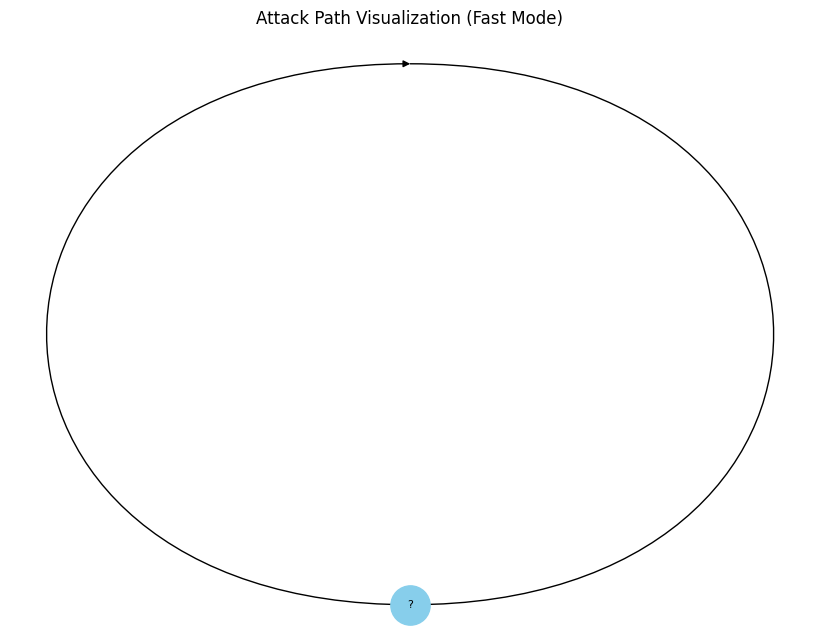

In [26]:
import os
import argparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# ====================================================
#  FAST MODE FLAG — TURN ON TO SPEED UP TRAINING
# ====================================================
FAST_MODE = True

# ====================================================
# Data Loading
# ====================================================
def load_dataset(path: str):
    if not os.path.exists(path):
        print(f"[WARN] Dataset not found at {path}, creating synthetic demo dataset...")
        n = 200
        df = pd.DataFrame({
            "srcip": np.random.choice(["10.0.0.1", "10.0.0.2", "192.168.1.1"], size=n),
            "dstip": np.random.choice(["172.16.0.1", "8.8.8.8", "1.1.1.1"], size=n),
            "proto": np.random.choice(["tcp", "udp", "icmp"], size=n),
            "duration": np.random.rand(n) * 100,
            "bytes": np.random.randint(10, 1000, size=n),
            "attack_cat": np.random.choice(["Normal", "DoS", "Exploits"], size=n)
        })
        return df
    print(f"[INFO] Loading dataset from {path}")
    return pd.read_csv(path)

# ====================================================
# Preprocessing
# ====================================================
def preprocess(df: pd.DataFrame):
    df = df.copy()
    label_col = next((c for c in ["attack_cat", "label", "class"] if c in df.columns), None)
    if label_col is None:
        raise ValueError("No label column found")

    y = df[label_col].fillna("Normal").astype(str)
    X = df.drop(columns=[label_col])

    # Drop unnecessary string cols
    drop_cols = [c for c in X.columns if X[c].dtype == "O" and c not in ["srcip", "dstip", "proto"]]
    X = X.drop(columns=drop_cols)

    enc = LabelEncoder()
    for c in ["proto", "srcip", "dstip"]:
        if c in X.columns:
            X[c] = enc.fit_transform(X[c].astype(str))

    # Extra engineered feature
    if "duration" in X.columns and "bytes" in X.columns:
        X["bytes_per_sec"] = X["bytes"] / (X["duration"] + 1e-5)

    # Normalize numeric features
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    y_enc = LabelEncoder().fit_transform(y)
    return X, y_enc, y

# ====================================================
# Balancing (Optional in Fast Mode)
# ====================================================
def balance_data(X, y):
    if FAST_MODE:
        print("[INFO] Skipping SMOTE for speed (Fast Mode)")
        return X, y
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

# ====================================================
# Model Training (Simplified & Fast)
# ====================================================
def train_model(X, y):
    print("[INFO] Training simplified RandomForest model...")
    model = RandomForestClassifier(
        n_estimators=100 if FAST_MODE else 300,
        max_depth=10 if FAST_MODE else None,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X, y)
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    print(f"[INFO] Training accuracy: {acc:.3f}")
    print(classification_report(y, preds))
    return model, preds

# ====================================================
# Attack Path Graph (Fast)
# ====================================================
def extract_attack_path(df: pd.DataFrame, y: pd.Series):
    G = nx.DiGraph()
    # Only use a few rows in Fast Mode
    subset = df.head(200 if FAST_MODE else len(df))
    for _, row in subset.iterrows():
        s = str(row.get("srcip", "?"))
        d = str(row.get("dstip", "?"))
        p = str(row.get("proto", "?"))
        label = str(row.get("attack_cat", ""))
        G.add_edge(s, d, proto=p, label=label)
    return G

# ====================================================
# Poster Visualization (Lightweight)
# ====================================================
def render_poster(G: nx.DiGraph, output="cyber_forensics_poster.png"):
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=800, font_size=8)
    plt.title("Attack Path Visualization (Fast Mode)")
    plt.tight_layout()
    plt.savefig(output, dpi=120)
    print(f"[INFO] Poster saved to {output}")
    return output

# ====================================================
# Main
# ====================================================
def main():
    data_path = os.environ.get("DATA_PATH", "datasets\\UNSW_NB15_training-set.csv")
    df = load_dataset(data_path)
    if FAST_MODE and len(df) > 10000:
        df = df.sample(n=5000, random_state=42)
        print("[INFO] Using 5k sample for speed")

    X, y_enc, y = preprocess(df)
    X_bal, y_bal = balance_data(X, y_enc)

    model, preds = train_model(X_bal, y_bal)
    joblib.dump(model, "trained_model_fast.joblib")

    df["attack_cat"] = y.values
    G = extract_attack_path(df, y)
    render_poster(G)

# ====================================================
if __name__ == "__main__":
    main()


In [27]:
pip install pyvis

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import pandas as pd
import networkx as nx
from pyvis.network import Network

# Load dataset
data = pd.read_csv("datasets\cybersecurity_attacks.csv")
print(data.columns.tolist())
# Create a directed graph
G = nx.DiGraph()

# Iterate through rows to build nodes and edges
for _, row in data.iterrows():
    src = row['Source IP Address']
    dst = row['Destination IP Address']
    protocol = row['Protocol']
    attack = row['Attack Type']
    severity = row['Severity Level']

    # Add nodes (devices as squares with names)
    G.add_node(src, shape="square", label=f"{src}\n(Source)", color="lightblue")
    G.add_node(dst, shape="square", label=f"{dst}\n(Destination)", color="lightgreen")

    # Edge label: protocol + attack
    edge_label = f"{protocol} | {attack if pd.notna(attack) else 'No Attack'}"

    # Edge color and danger symbol ⚠️ for attack traffic
    if pd.notna(attack) and attack.strip() != "":
        edge_label += " ⚠️"
        edge_color = "red"
    else:
        edge_color = "gray"

    # Add edge
    G.add_edge(src, dst, label=edge_label, color=edge_color)

# Create PyVis network
net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", directed=True)

# Convert NetworkX graph into PyVis network
net.from_nx(G)

# Save and show
net.write_html("cyber_attac" \
"k_network1.html")
print("Visualization saved as 'cyber_attack_network1.html'")

['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']
Visualization saved as 'cyber_attack_network1.html'


In [29]:
!pip install pyvis


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import pandas as pd
import networkx as nx
from pyvis.network import Network

# Load dataset
data = pd.read_csv("datasets\cybersecurity_attacks.csv")

# Create a directed graph
G = nx.DiGraph()

# Iterate through rows to build nodes and edges
for _, row in data.iterrows():
    src = row['Source IP Address']
    dst = row['Destination IP Address']
    protocol = row['Protocol']
    attack = row['Attack Type']
    severity = row['Severity Level']

    # Add nodes (devices as squares with names)
    G.add_node(src, shape="square", label=f"{src}\n(Source)", color="lightblue")
    G.add_node(dst, shape="square", label=f"{dst}\n(Destination)", color="lightgreen")

    # Edge label: protocol + attack
    edge_label = f"{protocol} | {attack if pd.notna(attack) else 'No Attack'}"

    # Edge color and danger symbol ⚠️ for attack traffic
    if pd.notna(attack) and attack.strip() != "":
        edge_label += " ⚠️"
        edge_color = "red"
    else:
        edge_color = "gray"

    # Add edge
    G.add_edge(src, dst, label=edge_label, color=edge_color)

# Create PyVis network
net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", directed=True)

# Convert NetworkX graph into PyVis network
net.from_nx(G)

# Save graph to HTML (no auto-open, avoids render bug)
net.save_graph("cyber_attack_network1.html")

print("Visualization saved as 'cyber_attack_network1.html' ✅")

Visualization saved as 'cyber_attack_network1.html' ✅


In [31]:
import numpy as np
import pandas as pd

In [32]:
data = pd.read_csv("datasets\cybersecurity_attacks.csv")
print(data.columns.tolist())

['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


In [33]:
import pandas as pd
import json

# Load your DataFrame
df = pd.read_csv("datasets\cybersecurity_attacks.csv")

# Build nodes dictionary to ensure uniqueness
nodes = {}
for _, row in df.iterrows():
    src_ip = row['Source IP Address']
    src_device = row.get('Device Information', 'Unknown Device')
    if src_ip not in nodes:
        nodes[src_ip] = {"id": src_ip, "label": f"{src_ip}\n{src_device}"}
    dst_ip = row['Destination IP Address']
    dst_device = row.get('Device Information', 'Unknown Device')
    if dst_ip not in nodes:
        nodes[dst_ip] = {"id": dst_ip, "label": f"{dst_ip}\n{dst_device}"}

vis_nodes = list(nodes.values())

# Build edges list
edges = []
for _, row in df.iterrows():
    src = row['Source IP Address']
    dst = row['Destination IP Address']
    protocol = row['Protocol']
    attack_type = row['Attack Type']
    edges.append({
        "from": src,
        "to": dst,
        "label": f"{attack_type} ({protocol})"
    })

# Save to JSON
with open("output\\network_nodes.json", "w") as f:
    json.dump(vis_nodes, f, indent=2)
with open("output\\network_edges.json", "w") as f:
    json.dump(edges, f, indent=2)

In [34]:
import json
import random

# Load graph.json
with open("output/graph.json") as f:
    graph = json.load(f)

# Sample 100 nodes
sampled_nodes = random.sample(graph["nodes"], min(100, len(graph["nodes"])))

# Keep only links where both ends are in sampled_nodes
sampled_ids = {n["id"] for n in sampled_nodes}
sampled_links = [l for l in graph["links"] if l["source"] in sampled_ids and l["target"] in sampled_ids]

sampled_graph = {"nodes": sampled_nodes, "links": sampled_links}

with open("output/graph_sample.json", "w") as f:
    json.dump(sampled_graph, f, indent=2)

# Attack paths sampling
with open("output/attack_paths.json") as f:
    paths = json.load(f)

sampled_paths = random.sample(paths, min(200, len(paths)))

with open("output/attack_paths_sample.json", "w") as f:
    json.dump(sampled_paths, f, indent=2)

print("✅ Sampled files created: graph_sample.json & attack_paths_sample.json")


✅ Sampled files created: graph_sample.json & attack_paths_sample.json


In [35]:
pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

# =====================================
# 1. Load Dataset
# =====================================
train_path = r"datasets\UNSW_NB15_training-set.csv"
test_path  = r"datasets\UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# =====================================
# 2. Drop Non-Useful Columns
# =====================================
drop_cols = ['id', 'attack_cat']
train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# =====================================
# 3. Separate Categorical Columns
# =====================================
categorical_cols = train_df.select_dtypes(include=['object']).columns

# =====================================
# 4. Safe Encoding (NO unseen label error)
# =====================================
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = encoder.transform(test_df[categorical_cols])

# =====================================
# 5. Split Features & Target
# =====================================
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# =====================================
# 6. Feature Scaling
# =====================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# =====================================
# 7. Handle Class Imbalance
# =====================================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [37]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

# =====================================
# 1. Load Dataset
# =====================================
train_path = r"datasets\UNSW_NB15_training-set.csv"
test_path  = r"datasets\UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# =====================================
# 2. Drop Non-Useful Columns
# =====================================
drop_cols = ['id', 'attack_cat']
train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# =====================================
# 3. Separate Categorical Columns
# =====================================
categorical_cols = train_df.select_dtypes(include=['object']).columns

# =====================================
# 4. Safe Encoding (NO unseen label error)
# =====================================
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = encoder.transform(test_df[categorical_cols])

# =====================================
# 5. Split Features & Target
# =====================================
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# =====================================
# 6. Feature Scaling
# =====================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# =====================================
# 7. Handle Class Imbalance
# =====================================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# =====================================
# 8. Define Models
# =====================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200
    ),
    
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),
    
    "SVM": SVC(
        kernel='rbf',
        probability=True
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    ),
    
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=10,
        random_state=42
    )
}

# =====================================
# 9. Train & Evaluate Models
# =====================================
print("\n================ MODEL RESULTS ================")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# =====================================
# 10. Ensemble Model (BEST PERFORMANCE)
# =====================================
ensemble = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('xgb', models["XGBoost"]),
        ('lgbm', models["LightGBM"])
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

print("\n================ ENSEMBLE MODEL ================")
print("Accuracy:", accuracy_score(y_test, y_pred_ens))
print(classification_report(y_test, y_pred_ens))



================ MODEL RESULTS ================

Logistic Regression
Accuracy: 0.8577742798318705
              precision    recall  f1-score   support

           0       0.71      0.95      0.81     56000
           1       0.97      0.81      0.89    119341

    accuracy                           0.86    175341
   macro avg       0.84      0.88      0.85    175341
weighted avg       0.89      0.86      0.86    175341


Random Forest
Accuracy: 0.8994359562224465
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     56000
           1       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341


Gradient Boosting
Accuracy: 0.899926429072493
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     56000
           1       0.99      0.86      0.92    

KeyboardInterrupt: 

MULTICLASS

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

# =====================================
# 1. Load Dataset
# =====================================
train_path = r"datasets\UNSW_NB15_training-set.csv"
test_path  = r"datasets\UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# =====================================
# 2. Keep attack_cat as TARGET
# =====================================
train_df = train_df.drop(columns=['id'], errors='ignore')
test_df  = test_df.drop(columns=['id'], errors='ignore')

# Replace NaN attack_cat with 'Normal'
train_df['attack_cat'] = train_df['attack_cat'].fillna('Normal')
test_df['attack_cat']  = test_df['attack_cat'].fillna('Normal')

# =====================================
# 3. Encode Target (Multi-Class)
# =====================================
label_encoder = LabelEncoder()

combined_labels = pd.concat([train_df['attack_cat'], test_df['attack_cat']])
label_encoder.fit(combined_labels)

y_train = label_encoder.transform(train_df['attack_cat'])
y_test  = label_encoder.transform(test_df['attack_cat'])

# =====================================
# 4. Drop target & binary label from features
# =====================================
train_df = train_df.drop(columns=['attack_cat', 'label'])
test_df  = test_df.drop(columns=['attack_cat', 'label'])

# =====================================
# 5. Encode Categorical Features Safely
# =====================================
categorical_cols = train_df.select_dtypes(include=['object']).columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = encoder.transform(test_df[categorical_cols])

# =====================================
# 6. Feature Scaling
# =====================================
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df)
X_test  = scaler.transform(test_df)

# =====================================
# 7. Handle Class Imbalance (SMOTE)
# =====================================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# =====================================
# 8. Define Multi-Class Models
# =====================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        class_weight='balanced',
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=len(label_encoder.classes_),
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=12,
        objective='multiclass',
        num_class=len(label_encoder.classes_),
        random_state=42
    )
}

# =====================================
# 9. Train & Evaluate Models
# =====================================
print("\n=========== MULTI-CLASS RESULTS ===========")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_
    ))

# =====================================
# 10. Ensemble Model (BEST)
# =====================================
ensemble = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost']),
        ('lgbm', models['LightGBM'])
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

print("\n=========== ENSEMBLE MODEL ===========")
print("Accuracy:", accuracy_score(y_test, y_pred_ens))
print(classification_report(
    y_test, y_pred_ens,
    target_names=label_encoder.classes_
))



=========== MULTI-CLASS RESULTS ===========

Random Forest
Accuracy: 0.7491801689279747
                precision    recall  f1-score   support

      Analysis       0.05      0.05      0.05      2000
      Backdoor       0.10      0.14      0.12      1746
           DoS       0.34      0.63      0.44     12264
      Exploits       0.86      0.52      0.65     33393
       Fuzzers       0.69      0.17      0.27     18184
       Generic       0.96      0.98      0.97     40000
        Normal       0.78      0.98      0.87     56000
Reconnaissance       0.77      0.78      0.77     10491
     Shellcode       0.51      0.70      0.59      1133
         Worms       0.22      0.53      0.32       130

      accuracy                           0.75    175341
     macro avg       0.53      0.55      0.50    175341
  weighted avg       0.78      0.75      0.73    175341


Extra Trees
Accuracy: 0.7251013738942974
                precision    recall  f1-score   support

      Analysis       0.05

c:\Minor\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
Accuracy: 0.7573813312345657
                precision    recall  f1-score   support

      Analysis       0.05      0.00      0.01      2000
      Backdoor       0.18      0.09      0.12      1746
           DoS       0.34      0.73      0.46     12264
      Exploits       0.81      0.54      0.65     33393
       Fuzzers       0.68      0.14      0.23     18184
       Generic       0.98      0.98      0.98     40000
        Normal       0.77      0.98      0.86     56000
Reconnaissance       0.86      0.78      0.82     10491
     Shellcode       0.61      0.67      0.64      1133
         Worms       0.44      0.63      0.52       130

      accuracy                           0.76    175341
     macro avg       0.57      0.55      0.53    175341
  weighted avg       0.78      0.76      0.73    175341

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.133625 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [

c:\Minor\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=========== ENSEMBLE MODEL ===========
Accuracy: 0.7578204755305377
                precision    recall  f1-score   support

      Analysis       0.05      0.02      0.02      2000
      Backdoor       0.18      0.09      0.12      1746
           DoS       0.34      0.73      0.47     12264
      Exploits       0.82      0.54      0.65     33393
       Fuzzers       0.67      0.14      0.23     18184
       Generic       0.98      0.98      0.98     40000
        Normal       0.77      0.98      0.87     56000
Reconnaissance       0.87      0.77      0.82     10491
     Shellcode       0.62      0.68      0.65      1133
         Worms       0.41      0.60      0.49       130

      accuracy                           0.76    175341
     macro avg       0.57      0.55      0.53    175341
  weighted avg       0.78      0.76      0.74    175341



In [ ]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


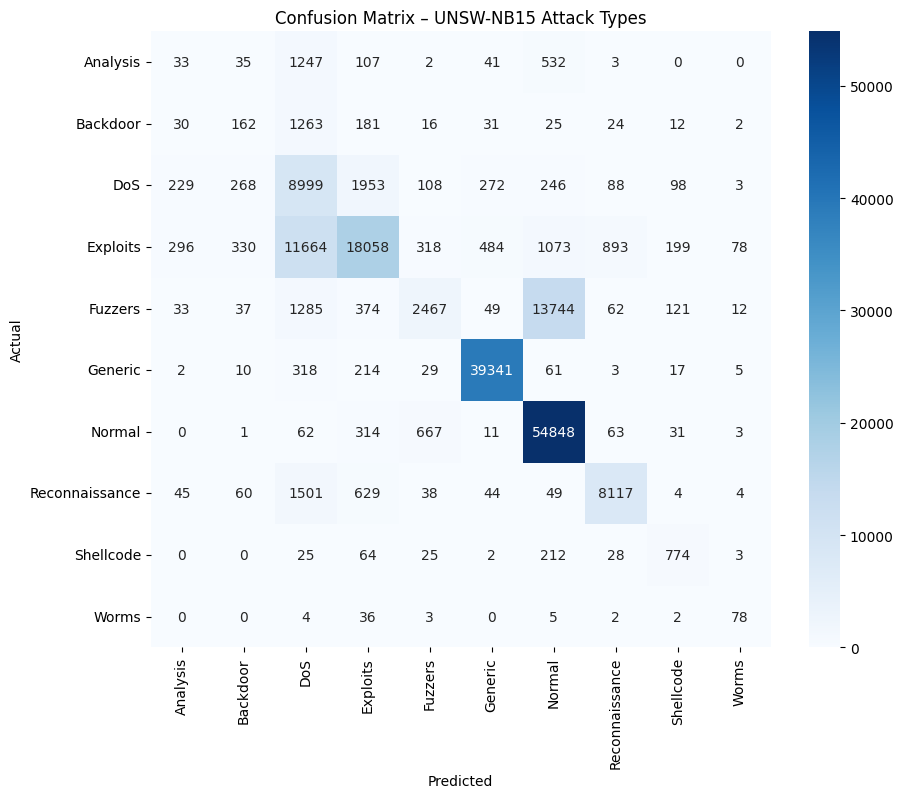

c:\Minor\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


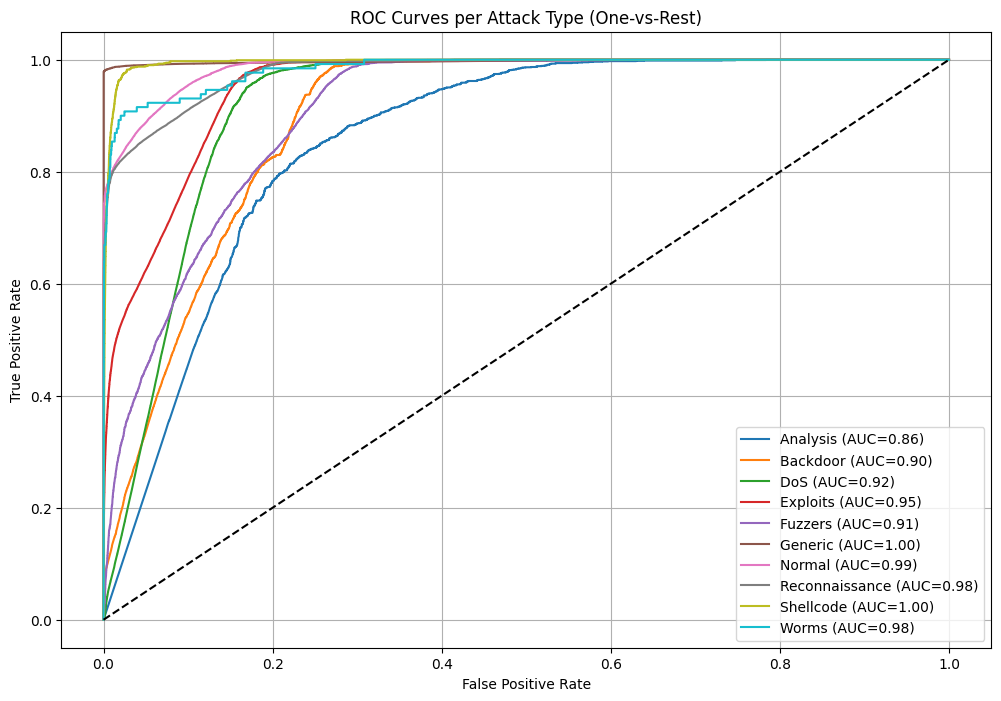


Top 15 Important Features:
             Feature  Importance
31      ct_state_ttl    0.141066
9               sttl    0.129944
38  ct_flw_http_mthd    0.107426
10              dttl    0.079818
2            service    0.064942
34  ct_dst_sport_ltm    0.055313
6             sbytes    0.048495
7             dbytes    0.040246
19              swin    0.035005
26             smean    0.032795
13             sloss    0.028433
27             dmean    0.028222
33  ct_src_dport_ltm    0.026257
14             dloss    0.019491
40        ct_srv_dst    0.016937


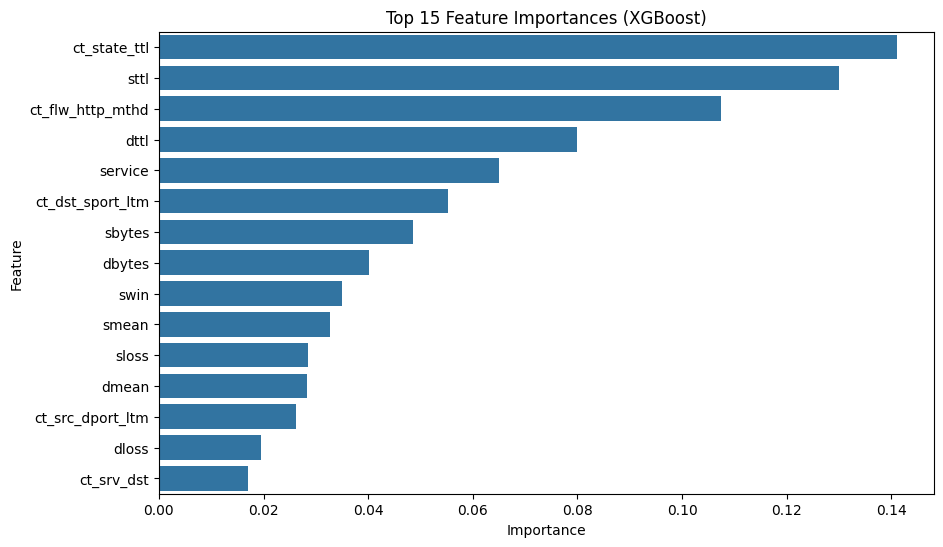

In [ ]:
# ===================== ALL-IN-ONE EVALUATION & EXPLAINABILITY =====================

import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# -------------------------------
# 1. CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test, y_pred_ens)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – UNSW-NB15 Attack Types")
plt.show()

# -------------------------------
# 2. ROC-AUC PER ATTACK TYPE
# -------------------------------
y_test_bin = label_binarize(
    y_test,
    classes=range(len(label_encoder.classes_))
)

y_score = ensemble.predict_proba(X_test)

plt.figure(figsize=(12, 8))

for i, attack in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{attack} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Attack Type (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# -------------------------------
# 3. FEATURE IMPORTANCE (XGBoost)
# -------------------------------
xgb_model = models["XGBoost"]

feature_importance = pd.DataFrame({
    "Feature": train_df.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()

# -------------------------------
# 4. SHAP EXPLAINABILITY
# -------------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# ---- Global SHAP importance
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=train_df.columns,
    plot_type="bar"
)

# ---- SHAP for a specific attack class (example: Exploits)
attack_name = "Exploits"
attack_index = list(label_encoder.classes_).index(attack_name)

shap.summary_plot(
    shap_values[attack_index],
    X_test,
    feature_names=train_df.columns
)

# ---- SHAP for single prediction (forensics view)
sample_id = 5

shap.force_plot(

    
    explainer.expected_value[attack_index],
    shap_values[attack_index][sample_id],
    X_test[sample_id],
    feature_names=train_df.columns,
    matplotlib=True
)



NameError: name 'models' is not defined

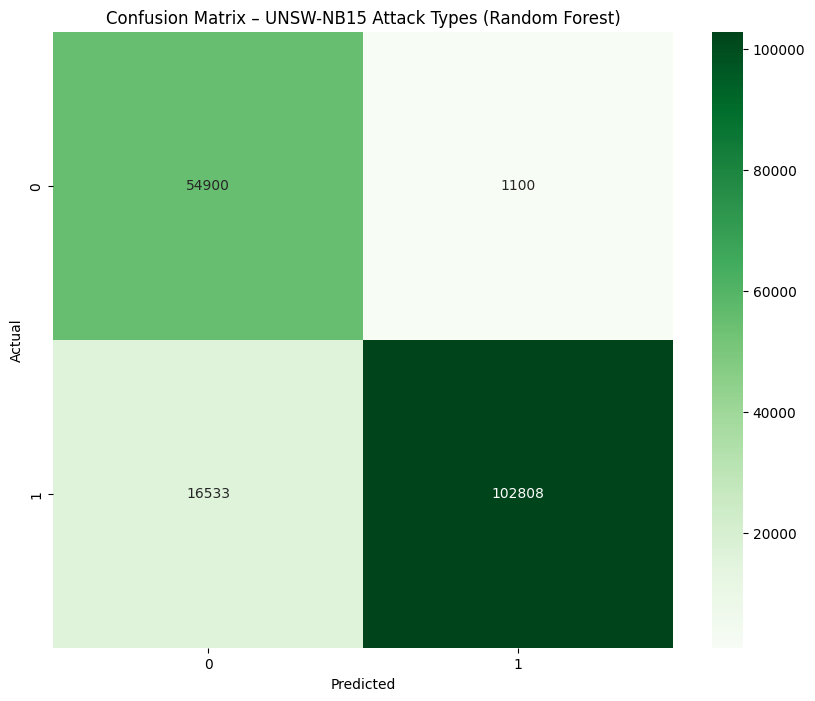

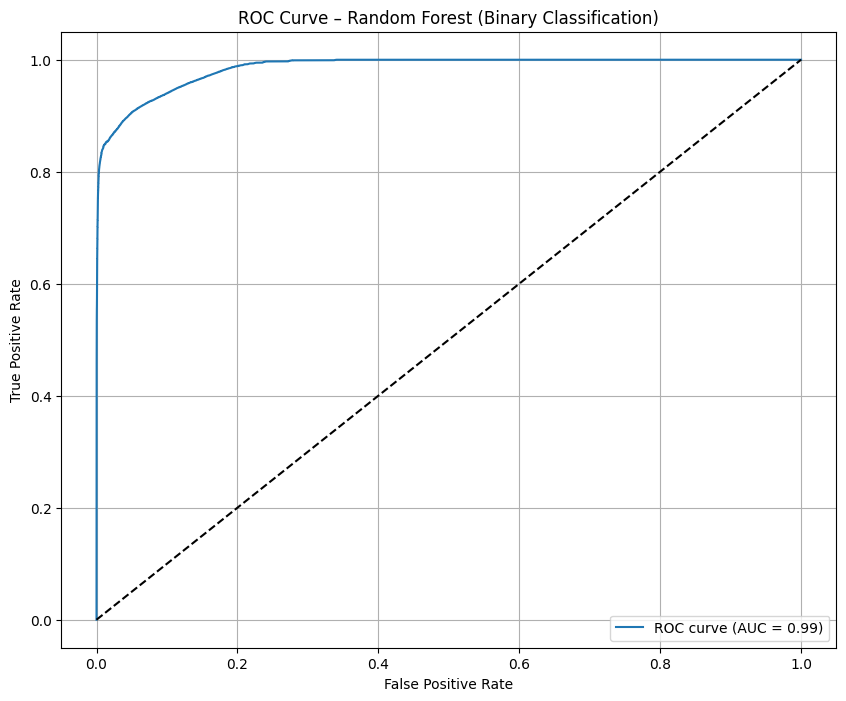


Top 15 Important Features (Random Forest):
       Feature  Importance
35  Feature_35    0.093338
9    Feature_9    0.071951
34  Feature_34    0.062971
6    Feature_6    0.059345
31  Feature_31    0.054816
26  Feature_26    0.054443
40  Feature_40    0.053900
8    Feature_8    0.053456
11  Feature_11    0.047246
7    Feature_7    0.039269
0    Feature_0    0.038864
30  Feature_30    0.027058
10  Feature_10    0.025402
23  Feature_23    0.025022
24  Feature_24    0.024061


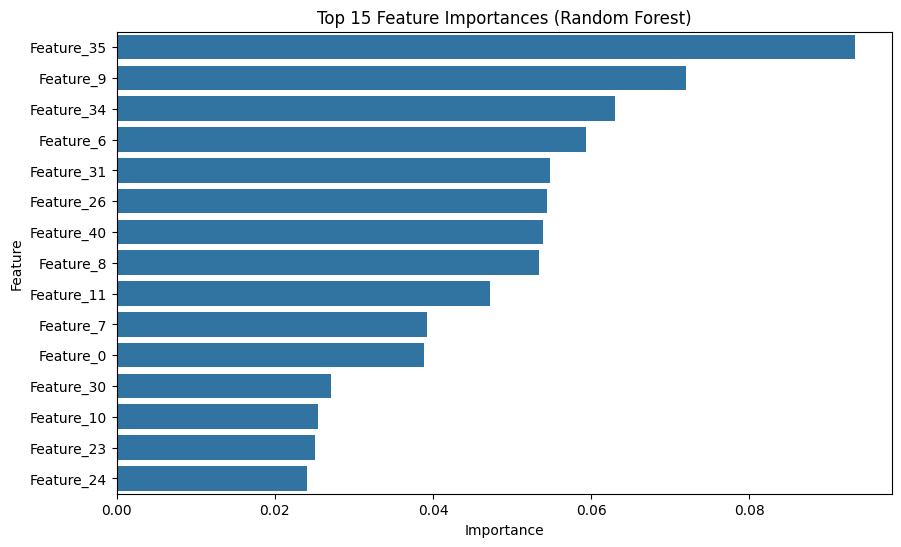

In [ ]:
# ===================== ALL-IN-ONE EVALUATION & EXPLAINABILITY (RANDOM FOREST) =====================

import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================================
# RANDOM FOREST MODEL (already trained)
# ==========================================================
rf_model = models["Random Forest"]

# ==========================================================
# CLASS NAMES (SAFE — no LabelEncoder needed)
# ==========================================================
CLASS_NAMES = rf_model.classes_

# ==========================================================
# FEATURE NAMES (NumPy-safe)
# ==========================================================
FEATURE_NAMES = [f"Feature_{i}" for i in range(X_train.shape[1])]

# ==========================================================
# PREDICTIONS
# ==========================================================
y_pred_rf = rf_model.predict(X_test)
y_score_rf = rf_model.predict_proba(X_test)

# -------------------------------
# 1. CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – UNSW-NB15 Attack Types (Random Forest)")
plt.show()

# -------------------------------
# 2. ROC–AUC PER ATTACK TYPE
# -------------------------------
# -------------------------------
# 2. ROC–AUC (ROBUST: Binary OR Multi-class)
# -------------------------------
n_classes = len(rf_model.classes_)

plt.figure(figsize=(10, 8))

# ---------- BINARY CLASSIFICATION ----------
if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, y_score_rf[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve – Random Forest (Binary Classification)")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# ---------- MULTI-CLASS CLASSIFICATION ----------
else:
    y_test_bin = label_binarize(y_test, classes=rf_model.classes_)

    for i, attack in enumerate(rf_model.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{attack} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves per Attack Type (Random Forest)")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

# -------------------------------
# 3. FEATURE IMPORTANCE (Random Forest)
# -------------------------------
rf_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features (Random Forest):")
print(rf_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance.head(15)
)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

# -------------------------------
# 4. SHAP EXPLAINABILITY (Random Forest)
# -------------------------------
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

# ---- Global SHAP importance
shap.summary_plot(
    rf_shap_values,
    X_test,
    feature_names=FEATURE_NAMES,
    plot_type="bar"
)

# ---- SHAP for a specific attack class (example: Exploits)
attack_name = "Exploits"

# find index safely
attack_index = list(CLASS_NAMES).index(attack_name) if attack_name in CLASS_NAMES else 0

shap.summary_plot(
    rf_shap_values[attack_index],
    X_test,
    feature_names=FEATURE_NAMES
)

# ---- SHAP for single prediction (forensics-level explanation)
sample_id = 5
x_sample = X_test[sample_id]

shap.force_plot(
    rf_explainer.expected_value[attack_index],
    rf_shap_values[attack_index][sample_id],
    x_sample,
    feature_names=FEATURE_NAMES,
    matplotlib=True
)


In [ ]:
# -------------------------------
# FEATURE IMPORTANCE (LightGBM)
# -------------------------------
lgbm_model = models["LightGBM"]

lgbm_importance = pd.DataFrame({
    "Feature": train_df.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features (LightGBM):")
print(lgbm_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=lgbm_importance.head(15)
)
plt.title("Top 15 Feature Importances (LightGBM)")
plt.show()
# -------------------------------
# SHAP (LightGBM)
# -------------------------------
lgbm_explainer = shap.TreeExplainer(lgbm_model)
lgbm_shap_values = lgbm_explainer.shap_values(X_test)

# ---- Global SHAP importance
shap.summary_plot(
    lgbm_shap_values,
    X_test,
    feature_names=train_df.columns,
    plot_type="bar"
)

# ---- Per-class SHAP (example: Exploits)
shap.summary_plot(
    lgbm_shap_values[attack_index],
    X_test,
    feature_names=train_df.columns
)


NotFittedError: No feature_importances found. Need to call fit beforehand.

Deep learning models

In [ ]:
pip install tenserflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tenserflow (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tenserflow


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

# =====================================
# 1. Load Dataset
# =====================================
train_path = r"datasets\UNSW_NB15_training-set.csv"
test_path  = r"datasets\UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# =====================================
# 2. Drop Non-Useful Columns
# =====================================
drop_cols = ['id', 'attack_cat']
train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# =====================================
# 3. Separate Categorical Columns
# =====================================
categorical_cols = train_df.select_dtypes(include=['object']).columns

# =====================================
# 4. Safe Encoding (NO unseen label error)
# =====================================
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
test_df[categorical_cols]  = encoder.transform(test_df[categorical_cols])

# =====================================
# 5. Split Features & Target
# =====================================
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# =====================================
# 6. Feature Scaling
# =====================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# =====================================
# 7. Handle Class Imbalance
# =====================================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
